In [5]:
import os
import mne
import numpy as np
# from sentry_sdk.utils import epoch
from sklearn.preprocessing import StandardScaler
import scipy.io as sio
from torch import optim
from typing import List
from torch.utils.data import DataLoader,TensorDataset
from sklearn.metrics import classification_report,confusion_matrix
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def calculate_accuracy(loader:DataLoader,model:nn.Module,device:str)->float:
    correct = 0
    total = 0
    with torch.no_grad():
        for datas,labels in loader:
            datas,labels = datas.to(device),labels.to(device)
            outputs = model(datas)
            _,predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

def get_losses(losses:List[float],loader:DataLoader,model:nn.Module,device:str)->List[float]:
    loss = 0
    with torch.no_grad():
        for i,(inputs,targets)in enumerate(loader):
            inputs,targets = inputs.to(device),targets.to(device)
            outputs = model(inputs)
            l = criterion(outputs,targets)
            loss += l.item()
        loss /= len(loader)
        losses.append(loss)
    return losses
def get_predictions(loader:DataLoader,model:nn.Module,device:str):
    all_targets = []
    all_predictions = []
    with torch.no_grad():
        for i ,(inputs,targets) in enumerate(loader):
            inputs,targets = inputs.to(device),targets.to(device)
            outputs = model(inputs)
            _,predicted = torch.max(outputs,1)
            all_targets.extend(targets.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
    return all_targets,all_predictions

def loss_curve( epoches : int , train_losses : List[float],val_losses :List[float],model:str = '',folder_path = '',sub = '')->None:
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    plt.figure(figsize = (10,5))
    plt.plot(range(1,epoches +1),train_losses,label = 'Train Loss')
    plt.plot(range(1,epoches +1),val_losses,label = 'Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('loss')
    plt.title(f'Sub{sub+1} Training and Testing Loss Curve')
    plt.legend()
    img_path = os.path.join(folder_path,'loss_curve.png')
    plt.savefig(img_path)
    plt.show(block = False)
    plt.close()

def plot_confusion_matrix(
        all_train_targets:np.ndarray,
        all_train_predictions:np.ndarray,
        all_test_targets:np.ndarray,
        all_test_predictions:np.ndarray,
        model:str = '',
        folder_path ='',
        sub = ''
)->None:
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    plt.figure(figsize = (8,6))
    cm = confusion_matrix(all_train_targets,all_train_predictions)
    sns.heatmap(cm,annot = True,fmt = 'd',cmap = 'Blues',xticklabels = range(2),yticklabels = range(2))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Sub{sub+1} Confusion Matrix-Train')
    plt.savefig(os.path.join(folder_path,f'Sub{sub+1} Confusion Matrix-Train'))
    plt.show(block = False)
    plt.close()

    plt.figure(figsize = (8,6))
    cm = confusion_matrix(all_test_targets,all_test_predictions)
    sns.heatmap(cm,annot = True,fmt = 'd',cmap = 'Blues',xticklabels =range(2),yticklabels = range(2))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Sub{sub+1} Confusion Matrix-Test')
    plt.savefig(os.path.join(folder_path,f'Sub{sub+1} Confusion Matrix-Test'))
    plt.show(block = False)
    plt.close()

def print_Confusion_matrix(
        all_train_targets:np.ndarray,
        all_train_predictions:np.ndarray,
        all_test_targets:np.ndarray,
        all_test_predictions:np.ndarray,
        model:str = '',
        folder_path ='',
        sub = ''
):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    report_train = classification_report(all_train_targets,all_train_predictions)
    report_test  = classification_report(all_test_targets, all_test_predictions)

    with open(os.path.join(folder_path,f'Sub{sub+1}Report.txt'),'w')as f:
        f.write('\nReport Train')
        f.write(report_train)
        f.write('\nReport Test')
        f.write(report_test)

In [3]:
class EEGNet(nn.Module):
    # def __init__(self, n_classes=4, channels=22, samples=1000,
    #              dropoutRate=0.5, kernelLength=32, kernelLength2=16,
    #              F1=16, D=2, F2=32):
    def __init__(self, n_classes=2, channels=17, samples=384,
                     drop_out=0.5, kernelLength=32, kernelLength2=16,
                     F1=16, D=2, F2=32):
        super(EEGNet, self).__init__()
        self.n_classes = n_classes
        self.channels = channels
        self.samples = samples
        # self.drop_out = dropoutRate
        self.drop_out = drop_out
        self.kernelLength = kernelLength
        self.kernelLength2 = kernelLength2
        self.F1 = F1
        self.D = D
        self.F2 = F2

        block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=self.F1,
                      kernel_size=(1,self.kernelLength), stride=1,
                      padding=(0,self.kernelLength//2),
                      bias=False
        ),
            nn.BatchNorm2d(num_features=self.F1)
        )

        block2 = nn.Sequential(
            nn.Conv2d(in_channels=self.F1,out_channels=self.F1*self.D,
                      kernel_size=(self.channels,1), groups=self.F1,
                      bias=False
                      ),
            nn.BatchNorm2d(num_features=self.F1*self.D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1,8)),
            nn.Dropout(p=self.drop_out)
        )

        block3 = nn.Sequential(
            nn.Conv2d(in_channels=self.F1*self.D,out_channels=self.F2,
                      kernel_size=(1,self.kernelLength2), stride=1,
                      padding=(0,self.kernelLength2//2),groups=self.F1*self.D,
                      bias=False
                      ),
            nn.Conv2d(in_channels=self.F2,out_channels=self.F2,
                      kernel_size=(1,1), stride=1,
                      bias=False),
            nn.BatchNorm2d(num_features=self.F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1,16)),
            nn.Dropout(p=self.drop_out)
        )

        self.EEGNetLayer = nn.Sequential(block1, block2, block3)
        # self.FlattenLayer = nn.Flatten()
        self.ClassifierBlock = nn.Sequential(nn.Linear(in_features=self.F2 * round((self.samples // 8) // 16),
                                                       out_features=self.n_classes,
                                                       bias=False),
                                             nn.Softmax(dim=1)
        )
        # self.model = nn.Sequential(self.EEGNetLayer, self.FlattenLayer, self.ClassifierBlock)
    def forward(self, x):
        if len(x.shape) != 4:
            x = torch.unsqueeze(x,1)
        x = self.EEGNetLayer(x)
        x = x.view(x.size()[0], -1)  # Flatten # [N, self.F2*1*T/32]
        x = self.ClassifierBlock(x)
        # x = self.model(x)

        return x

In [19]:
import h5py
import numpy as np

# 读取文件
with h5py.File('seed.mat', 'r') as f:
    # 查看文件里有哪些键（可选）
    print("文件中的变量：", list(f.keys()))

    # 提取数据（注意 v7.3 文件里数组通常需要转置或额外处理）
    EEGsample = np.array(f['EEGsample'])
    subindex   = np.array(f['subindex'])
    substate   = np.array(f['substate'])
    EEGsample = EEGsample.transpose(2,1,0)
print("EEGsample shape:", EEGsample.shape)
print("subindex shape:", subindex.shape)
print("substate shape:", substate.shape)


文件中的变量： ['EEGsample', 'subindex', 'substate']
EEGsample shape: (11396, 17, 384)
subindex shape: (1, 11396)
substate shape: (1, 11396)


In [20]:
save_path = os.path.join(os.getcwd(), 'results')
if not os.path.exists(save_path):
    os.makedirs(save_path)

path = os.path.join(save_path, 'EEGNet')
if not os.path.exists(path):
    os.makedirs(path)
report_path = os.path.join(path, 'report.txt')

torch.manual_seed(2024)


========== 开始第 1/22 折LOOCV（测试序号：0）==========
Fold [1/22], Epoch [1/500], Step [1/43], Loss: 0.6912
Fold [1/22], Epoch [1/500], Step [11/43], Loss: 0.6901
Fold [1/22], Epoch [1/500], Step [21/43], Loss: 0.6847
Fold [1/22], Epoch [1/500], Step [31/43], Loss: 0.6722
Fold [1/22], Epoch [1/500], Step [41/43], Loss: 0.6668
Fold [1/22], Epoch [101/500], Step [1/43], Loss: 0.4201
Fold [1/22], Epoch [101/500], Step [11/43], Loss: 0.4217
Fold [1/22], Epoch [101/500], Step [21/43], Loss: 0.4194
Fold [1/22], Epoch [101/500], Step [31/43], Loss: 0.4120
Fold [1/22], Epoch [101/500], Step [41/43], Loss: 0.4094
Fold [1/22], Epoch [201/500], Step [1/43], Loss: 0.4201
Fold [1/22], Epoch [201/500], Step [11/43], Loss: 0.4361
Fold [1/22], Epoch [201/500], Step [21/43], Loss: 0.4038
Fold [1/22], Epoch [201/500], Step [31/43], Loss: 0.4286
Fold [1/22], Epoch [201/500], Step [41/43], Loss: 0.3979
Fold [1/22], Epoch [301/500], Step [1/43], Loss: 0.3922
Fold [1/22], Epoch [301/500], Step [11/43], Loss: 0.4120

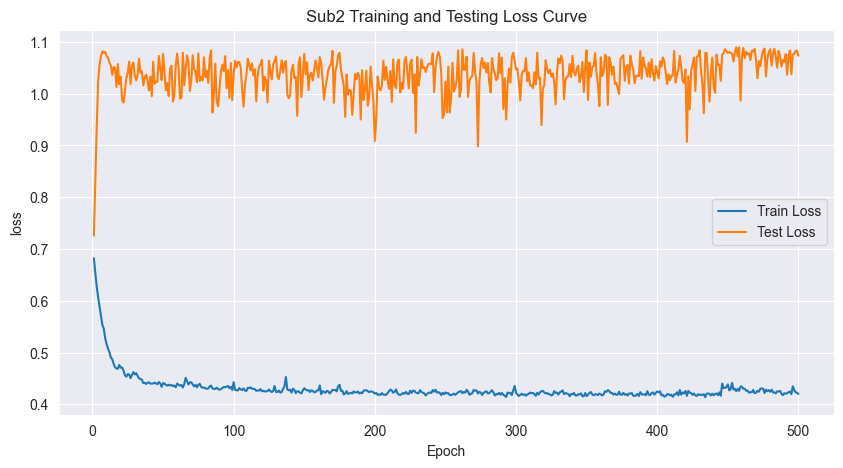

<Figure size 640x480 with 0 Axes>

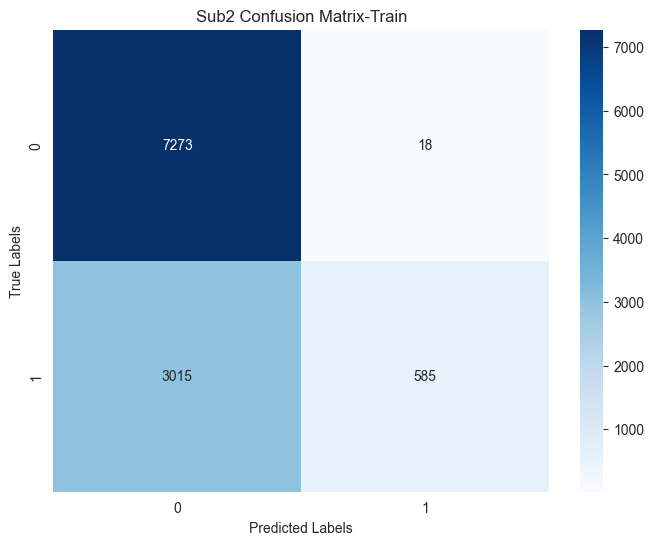

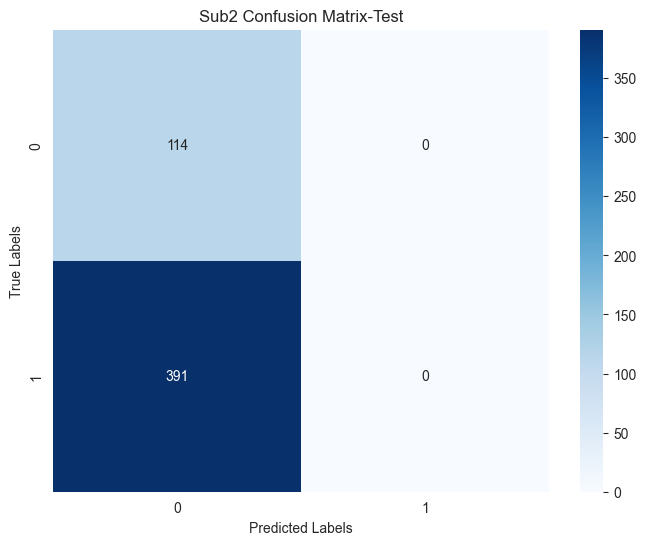

第 1 折（测试序号0）Acc: 22.57%

========== 开始第 2/22 折LOOCV（测试序号：1）==========
Fold [2/22], Epoch [1/500], Step [1/44], Loss: 0.6920
Fold [2/22], Epoch [1/500], Step [11/44], Loss: 0.6921
Fold [2/22], Epoch [1/500], Step [21/44], Loss: 0.6814
Fold [2/22], Epoch [1/500], Step [31/44], Loss: 0.6845
Fold [2/22], Epoch [1/500], Step [41/44], Loss: 0.6749
Fold [2/22], Epoch [101/500], Step [1/44], Loss: 0.4560
Fold [2/22], Epoch [101/500], Step [11/44], Loss: 0.4575
Fold [2/22], Epoch [101/500], Step [21/44], Loss: 0.4810
Fold [2/22], Epoch [101/500], Step [31/44], Loss: 0.4336
Fold [2/22], Epoch [101/500], Step [41/44], Loss: 0.4907
Fold [2/22], Epoch [201/500], Step [1/44], Loss: 0.4274
Fold [2/22], Epoch [201/500], Step [11/44], Loss: 0.4360
Fold [2/22], Epoch [201/500], Step [21/44], Loss: 0.4476
Fold [2/22], Epoch [201/500], Step [31/44], Loss: 0.4440
Fold [2/22], Epoch [201/500], Step [41/44], Loss: 0.4246
Fold [2/22], Epoch [301/500], Step [1/44], Loss: 0.4380
Fold [2/22], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

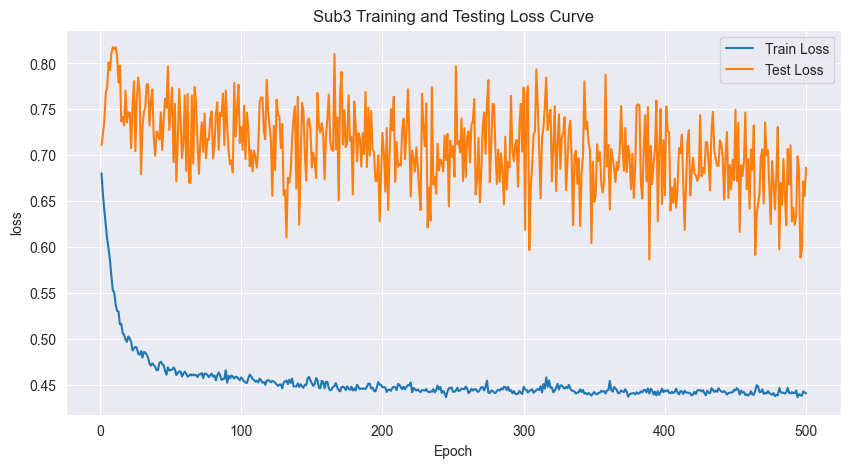

<Figure size 640x480 with 0 Axes>

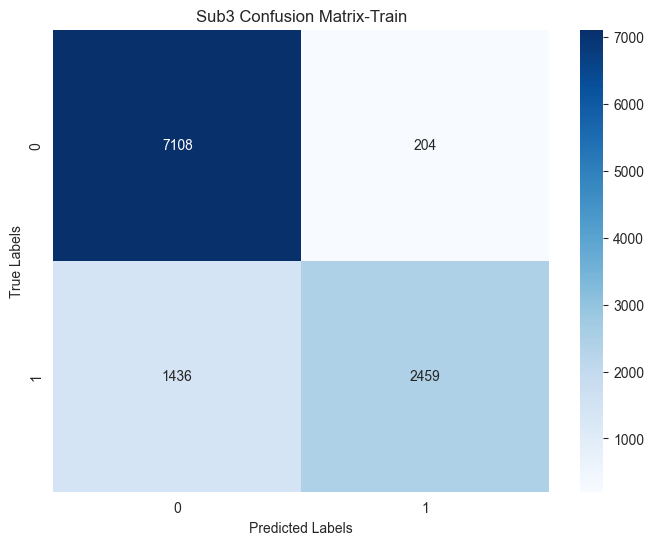

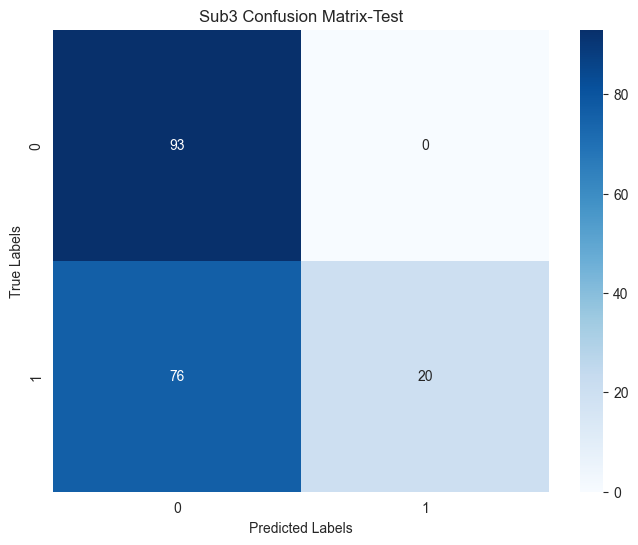

第 2 折（测试序号1）Acc: 59.79%

========== 开始第 3/22 折LOOCV（测试序号：2）==========
Fold [3/22], Epoch [1/500], Step [1/43], Loss: 0.7121
Fold [3/22], Epoch [1/500], Step [11/43], Loss: 0.6933
Fold [3/22], Epoch [1/500], Step [21/43], Loss: 0.6840
Fold [3/22], Epoch [1/500], Step [31/43], Loss: 0.6780
Fold [3/22], Epoch [1/500], Step [41/43], Loss: 0.6612
Fold [3/22], Epoch [101/500], Step [1/43], Loss: 0.4593
Fold [3/22], Epoch [101/500], Step [11/43], Loss: 0.4614
Fold [3/22], Epoch [101/500], Step [21/43], Loss: 0.4639
Fold [3/22], Epoch [101/500], Step [31/43], Loss: 0.4558
Fold [3/22], Epoch [101/500], Step [41/43], Loss: 0.4858
Fold [3/22], Epoch [201/500], Step [1/43], Loss: 0.4273
Fold [3/22], Epoch [201/500], Step [11/43], Loss: 0.4540
Fold [3/22], Epoch [201/500], Step [21/43], Loss: 0.4684
Fold [3/22], Epoch [201/500], Step [31/43], Loss: 0.4491
Fold [3/22], Epoch [201/500], Step [41/43], Loss: 0.4887
Fold [3/22], Epoch [301/500], Step [1/43], Loss: 0.5539
Fold [3/22], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

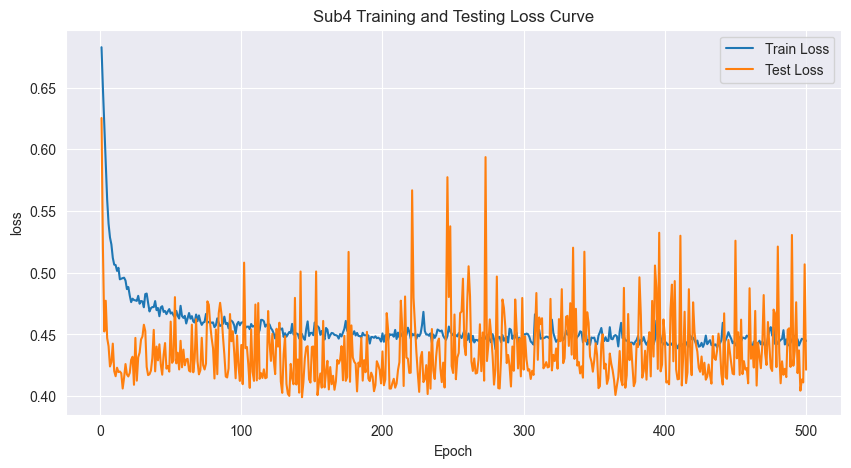

<Figure size 640x480 with 0 Axes>

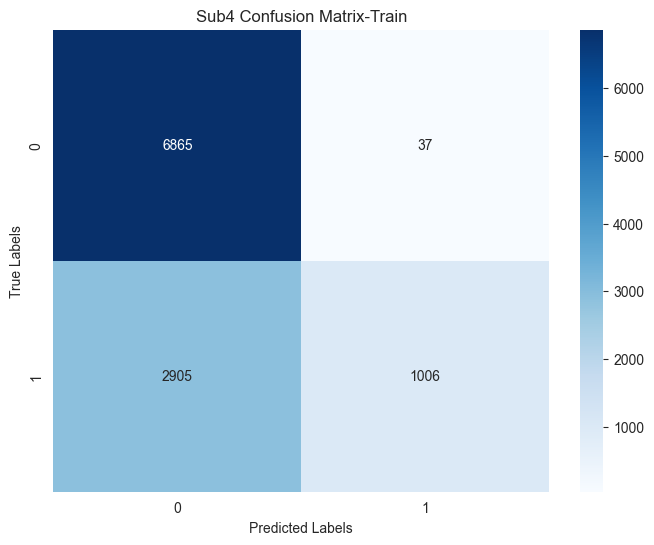

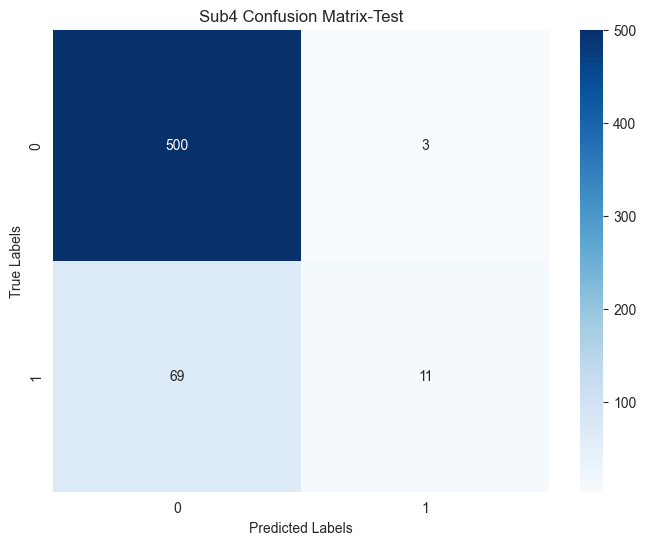

第 3 折（测试序号2）Acc: 87.65%

========== 开始第 4/22 折LOOCV（测试序号：3）==========
Fold [4/22], Epoch [1/500], Step [1/43], Loss: 0.6876
Fold [4/22], Epoch [1/500], Step [11/43], Loss: 0.6860
Fold [4/22], Epoch [1/500], Step [21/43], Loss: 0.6853
Fold [4/22], Epoch [1/500], Step [31/43], Loss: 0.6776
Fold [4/22], Epoch [1/500], Step [41/43], Loss: 0.6707
Fold [4/22], Epoch [101/500], Step [1/43], Loss: 0.4317
Fold [4/22], Epoch [101/500], Step [11/43], Loss: 0.4191
Fold [4/22], Epoch [101/500], Step [21/43], Loss: 0.4775
Fold [4/22], Epoch [101/500], Step [31/43], Loss: 0.4679
Fold [4/22], Epoch [101/500], Step [41/43], Loss: 0.4586
Fold [4/22], Epoch [201/500], Step [1/43], Loss: 0.4352
Fold [4/22], Epoch [201/500], Step [11/43], Loss: 0.4382
Fold [4/22], Epoch [201/500], Step [21/43], Loss: 0.4240
Fold [4/22], Epoch [201/500], Step [31/43], Loss: 0.4414
Fold [4/22], Epoch [201/500], Step [41/43], Loss: 0.4372
Fold [4/22], Epoch [301/500], Step [1/43], Loss: 0.4497
Fold [4/22], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

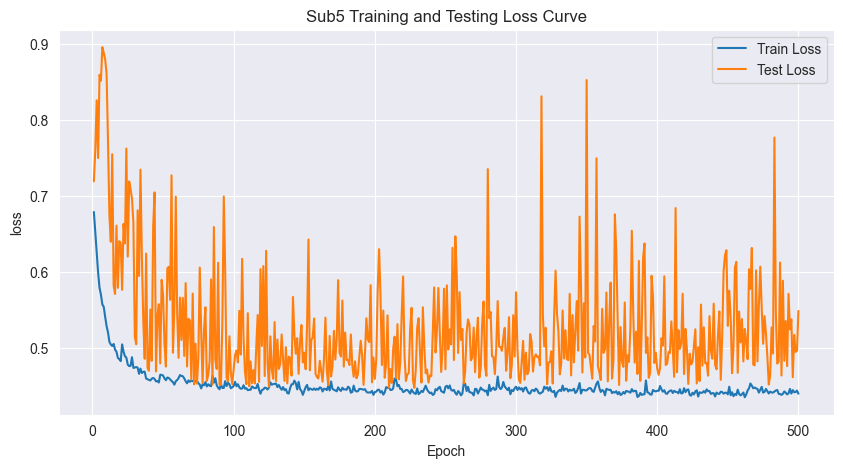

<Figure size 640x480 with 0 Axes>

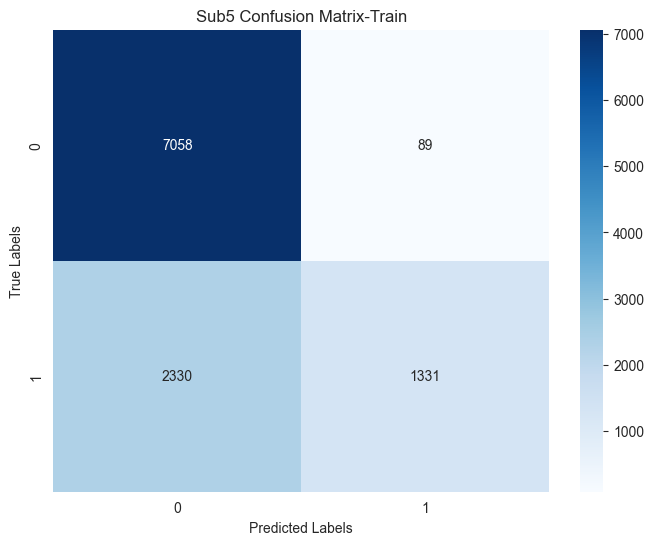

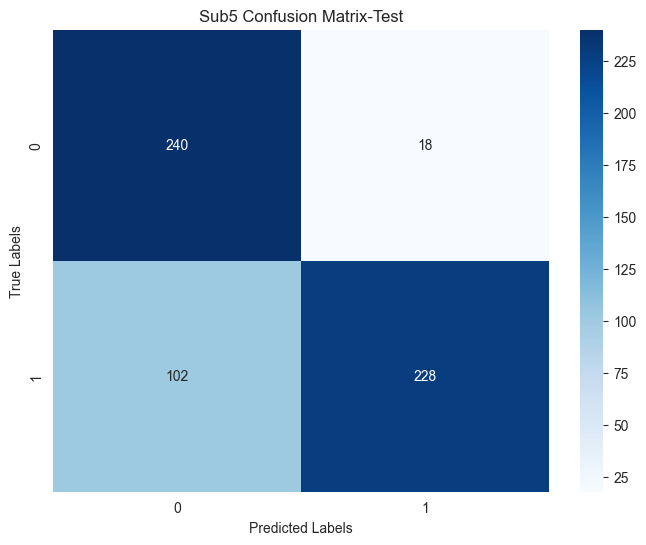

第 4 折（测试序号3）Acc: 79.59%

========== 开始第 5/22 折LOOCV（测试序号：4）==========
Fold [5/22], Epoch [1/500], Step [1/42], Loss: 0.6968
Fold [5/22], Epoch [1/500], Step [11/42], Loss: 0.6884
Fold [5/22], Epoch [1/500], Step [21/42], Loss: 0.6847
Fold [5/22], Epoch [1/500], Step [31/42], Loss: 0.6843
Fold [5/22], Epoch [1/500], Step [41/42], Loss: 0.6745
Fold [5/22], Epoch [101/500], Step [1/42], Loss: 0.4765
Fold [5/22], Epoch [101/500], Step [11/42], Loss: 0.4613
Fold [5/22], Epoch [101/500], Step [21/42], Loss: 0.4182
Fold [5/22], Epoch [101/500], Step [31/42], Loss: 0.4870
Fold [5/22], Epoch [101/500], Step [41/42], Loss: 0.4229
Fold [5/22], Epoch [201/500], Step [1/42], Loss: 0.5252
Fold [5/22], Epoch [201/500], Step [11/42], Loss: 0.4235
Fold [5/22], Epoch [201/500], Step [21/42], Loss: 0.4467
Fold [5/22], Epoch [201/500], Step [31/42], Loss: 0.4282
Fold [5/22], Epoch [201/500], Step [41/42], Loss: 0.4420
Fold [5/22], Epoch [301/500], Step [1/42], Loss: 0.4407
Fold [5/22], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

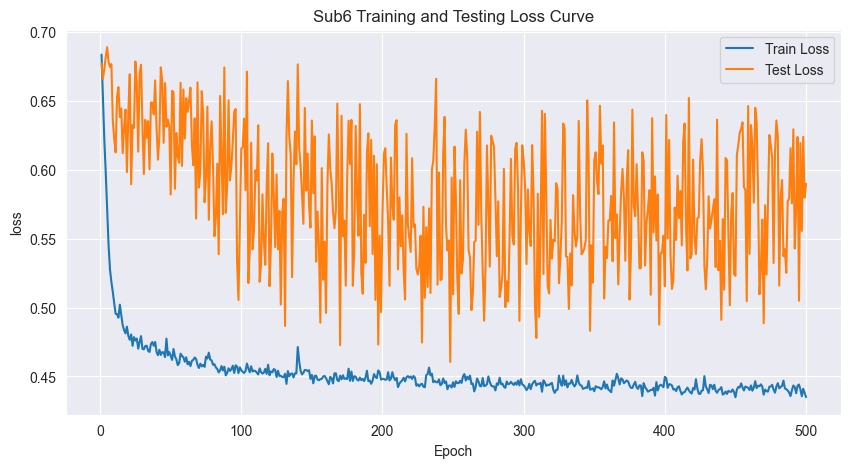

<Figure size 640x480 with 0 Axes>

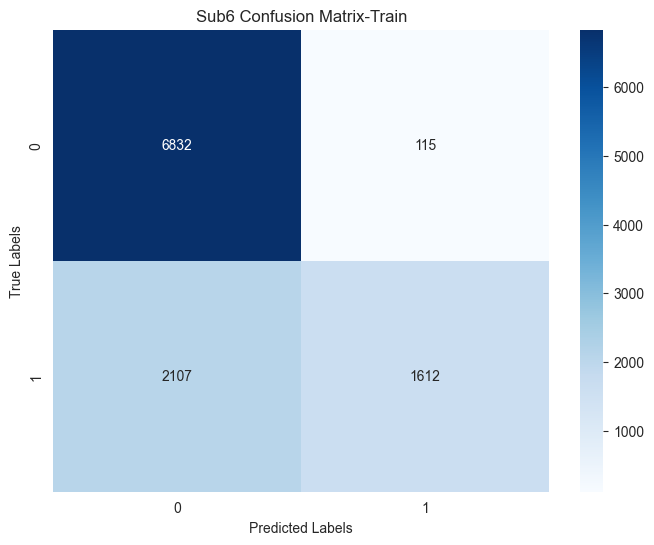

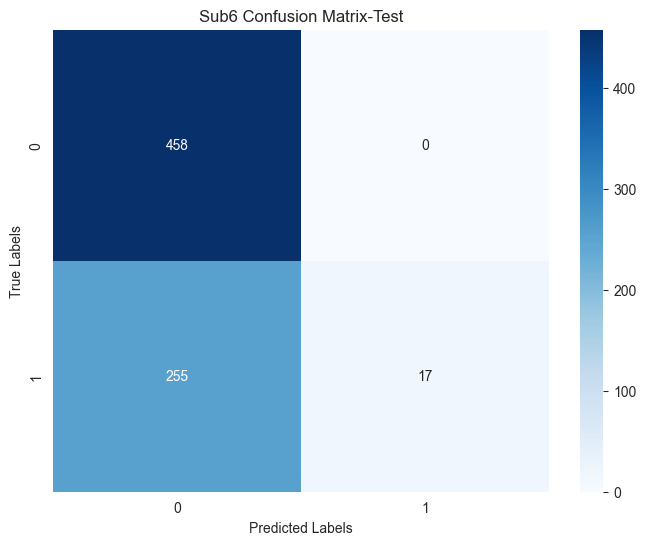

第 5 折（测试序号4）Acc: 65.07%

========== 开始第 6/22 折LOOCV（测试序号：5）==========
Fold [6/22], Epoch [1/500], Step [1/43], Loss: 0.6996
Fold [6/22], Epoch [1/500], Step [11/43], Loss: 0.6987
Fold [6/22], Epoch [1/500], Step [21/43], Loss: 0.6934
Fold [6/22], Epoch [1/500], Step [31/43], Loss: 0.6847
Fold [6/22], Epoch [1/500], Step [41/43], Loss: 0.6832
Fold [6/22], Epoch [101/500], Step [1/43], Loss: 0.4144
Fold [6/22], Epoch [101/500], Step [11/43], Loss: 0.4336
Fold [6/22], Epoch [101/500], Step [21/43], Loss: 0.4306
Fold [6/22], Epoch [101/500], Step [31/43], Loss: 0.4468
Fold [6/22], Epoch [101/500], Step [41/43], Loss: 0.4530
Fold [6/22], Epoch [201/500], Step [1/43], Loss: 0.4273
Fold [6/22], Epoch [201/500], Step [11/43], Loss: 0.4107
Fold [6/22], Epoch [201/500], Step [21/43], Loss: 0.4821
Fold [6/22], Epoch [201/500], Step [31/43], Loss: 0.4510
Fold [6/22], Epoch [201/500], Step [41/43], Loss: 0.4688
Fold [6/22], Epoch [301/500], Step [1/43], Loss: 0.4307
Fold [6/22], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

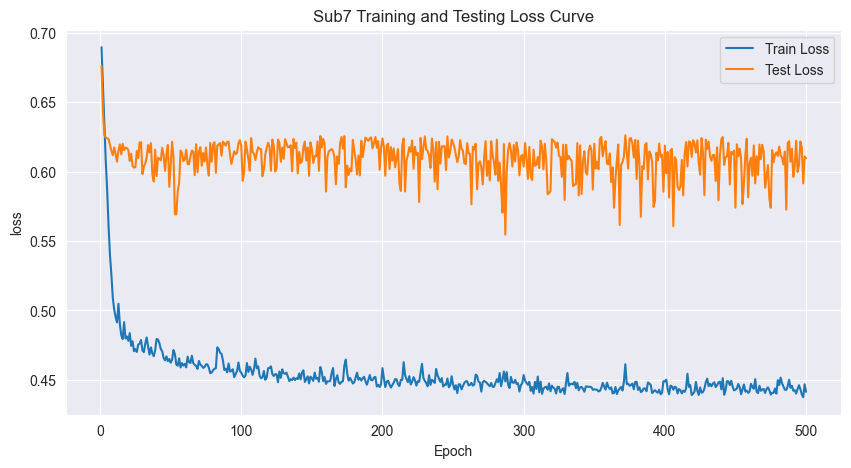

<Figure size 640x480 with 0 Axes>

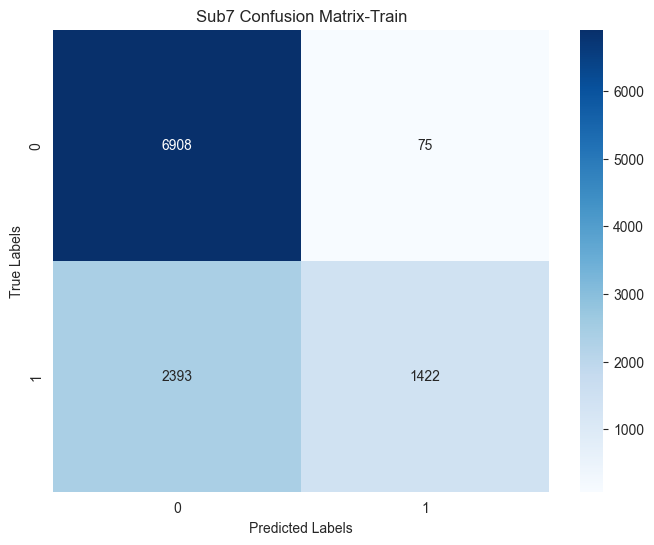

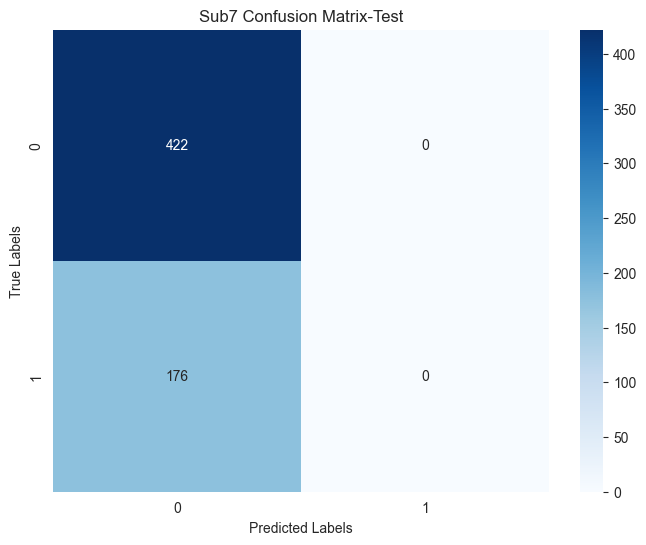

第 6 折（测试序号5）Acc: 70.57%

========== 开始第 7/22 折LOOCV（测试序号：6）==========
Fold [7/22], Epoch [1/500], Step [1/44], Loss: 0.6898
Fold [7/22], Epoch [1/500], Step [11/44], Loss: 0.6954
Fold [7/22], Epoch [1/500], Step [21/44], Loss: 0.6899
Fold [7/22], Epoch [1/500], Step [31/44], Loss: 0.6781
Fold [7/22], Epoch [1/500], Step [41/44], Loss: 0.6758
Fold [7/22], Epoch [101/500], Step [1/44], Loss: 0.4424
Fold [7/22], Epoch [101/500], Step [11/44], Loss: 0.4497
Fold [7/22], Epoch [101/500], Step [21/44], Loss: 0.4716
Fold [7/22], Epoch [101/500], Step [31/44], Loss: 0.4457
Fold [7/22], Epoch [101/500], Step [41/44], Loss: 0.4343
Fold [7/22], Epoch [201/500], Step [1/44], Loss: 0.4512
Fold [7/22], Epoch [201/500], Step [11/44], Loss: 0.4164
Fold [7/22], Epoch [201/500], Step [21/44], Loss: 0.4518
Fold [7/22], Epoch [201/500], Step [31/44], Loss: 0.4218
Fold [7/22], Epoch [201/500], Step [41/44], Loss: 0.4162
Fold [7/22], Epoch [301/500], Step [1/44], Loss: 0.4370
Fold [7/22], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

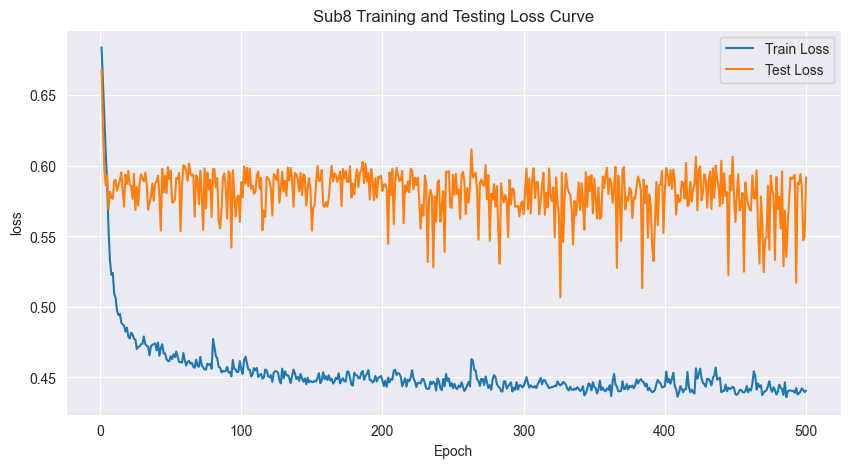

<Figure size 640x480 with 0 Axes>

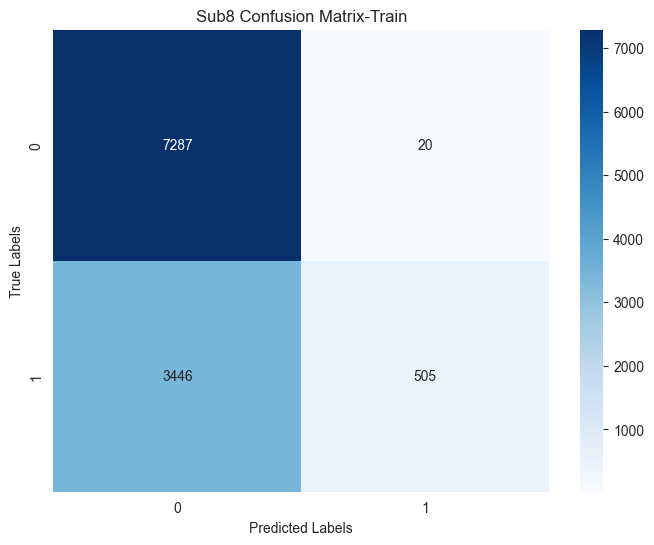

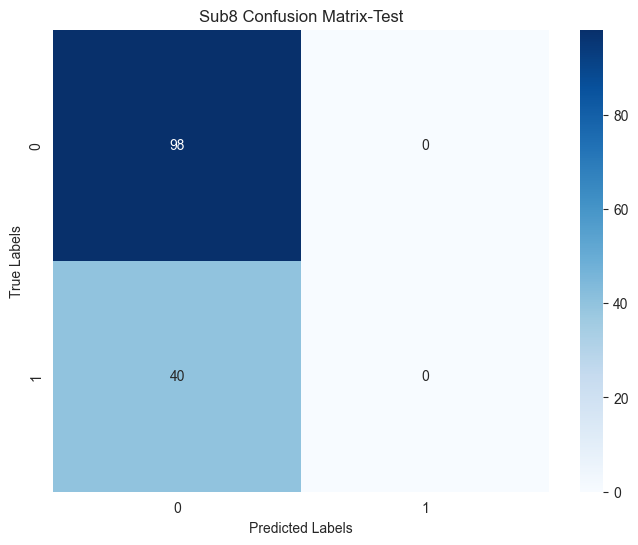

第 7 折（测试序号6）Acc: 71.01%

========== 开始第 8/22 折LOOCV（测试序号：7）==========
Fold [8/22], Epoch [1/500], Step [1/44], Loss: 0.6844
Fold [8/22], Epoch [1/500], Step [11/44], Loss: 0.6857
Fold [8/22], Epoch [1/500], Step [21/44], Loss: 0.6794
Fold [8/22], Epoch [1/500], Step [31/44], Loss: 0.6836
Fold [8/22], Epoch [1/500], Step [41/44], Loss: 0.6844
Fold [8/22], Epoch [101/500], Step [1/44], Loss: 0.4293
Fold [8/22], Epoch [101/500], Step [11/44], Loss: 0.4033
Fold [8/22], Epoch [101/500], Step [21/44], Loss: 0.4844
Fold [8/22], Epoch [101/500], Step [31/44], Loss: 0.4588
Fold [8/22], Epoch [101/500], Step [41/44], Loss: 0.4262
Fold [8/22], Epoch [201/500], Step [1/44], Loss: 0.4628
Fold [8/22], Epoch [201/500], Step [11/44], Loss: 0.4118
Fold [8/22], Epoch [201/500], Step [21/44], Loss: 0.4114
Fold [8/22], Epoch [201/500], Step [31/44], Loss: 0.4451
Fold [8/22], Epoch [201/500], Step [41/44], Loss: 0.4262
Fold [8/22], Epoch [301/500], Step [1/44], Loss: 0.4646
Fold [8/22], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

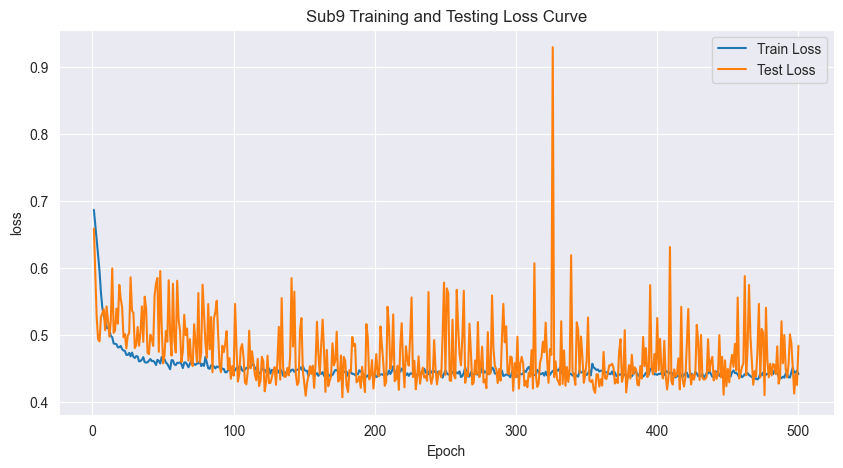

<Figure size 640x480 with 0 Axes>

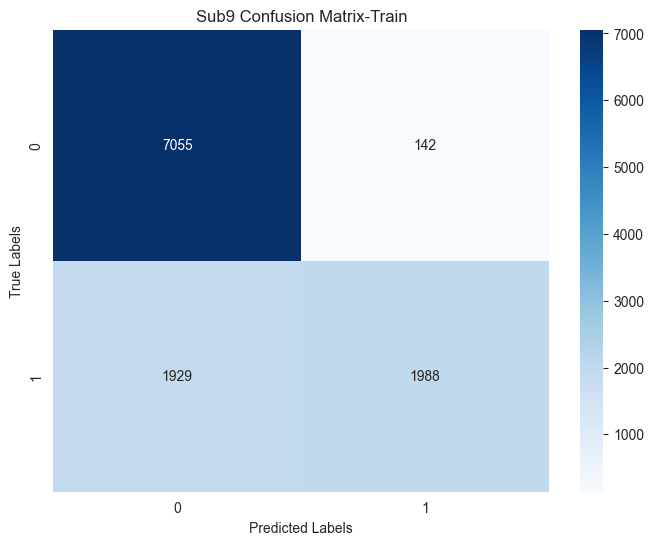

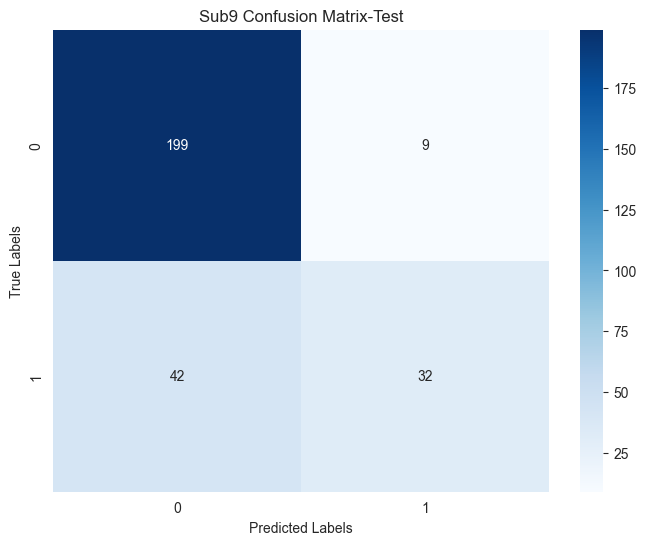

第 8 折（测试序号7）Acc: 81.91%

========== 开始第 9/22 折LOOCV（测试序号：8）==========
Fold [9/22], Epoch [1/500], Step [1/44], Loss: 0.6911
Fold [9/22], Epoch [1/500], Step [11/44], Loss: 0.6883
Fold [9/22], Epoch [1/500], Step [21/44], Loss: 0.6810
Fold [9/22], Epoch [1/500], Step [31/44], Loss: 0.6765
Fold [9/22], Epoch [1/500], Step [41/44], Loss: 0.6692
Fold [9/22], Epoch [101/500], Step [1/44], Loss: 0.4439
Fold [9/22], Epoch [101/500], Step [11/44], Loss: 0.4301
Fold [9/22], Epoch [101/500], Step [21/44], Loss: 0.4574
Fold [9/22], Epoch [101/500], Step [31/44], Loss: 0.4458
Fold [9/22], Epoch [101/500], Step [41/44], Loss: 0.5029
Fold [9/22], Epoch [201/500], Step [1/44], Loss: 0.4296
Fold [9/22], Epoch [201/500], Step [11/44], Loss: 0.4257
Fold [9/22], Epoch [201/500], Step [21/44], Loss: 0.5097
Fold [9/22], Epoch [201/500], Step [31/44], Loss: 0.4490
Fold [9/22], Epoch [201/500], Step [41/44], Loss: 0.4564
Fold [9/22], Epoch [301/500], Step [1/44], Loss: 0.4516
Fold [9/22], Epoch [301/500], St

<Figure size 640x480 with 0 Axes>

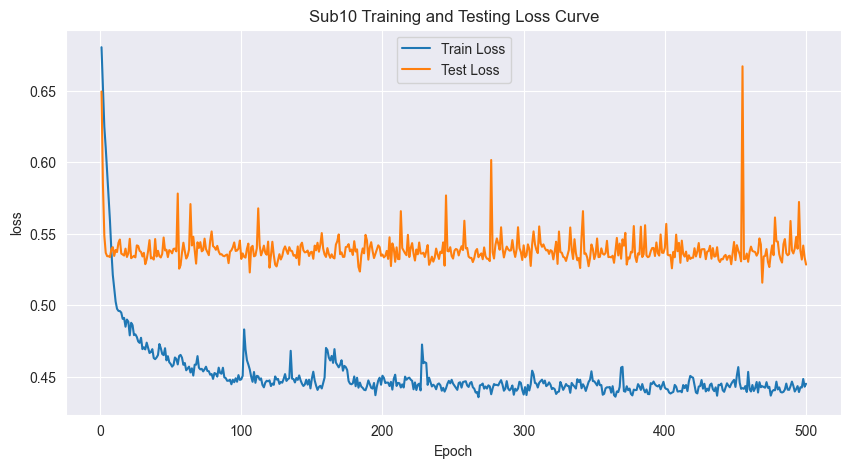

<Figure size 640x480 with 0 Axes>

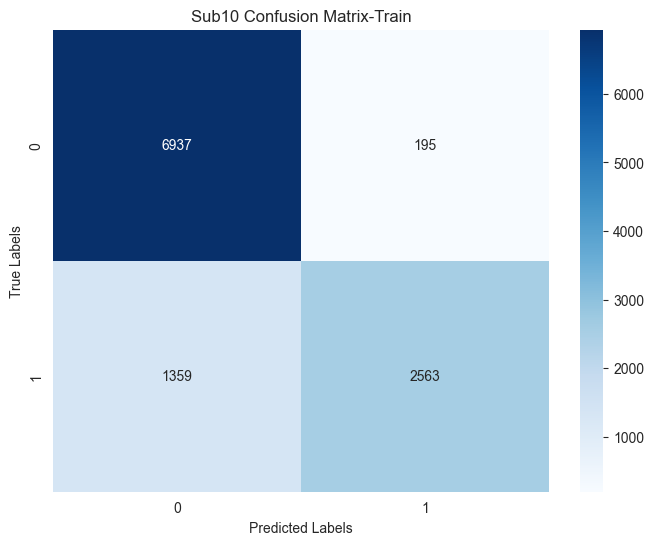

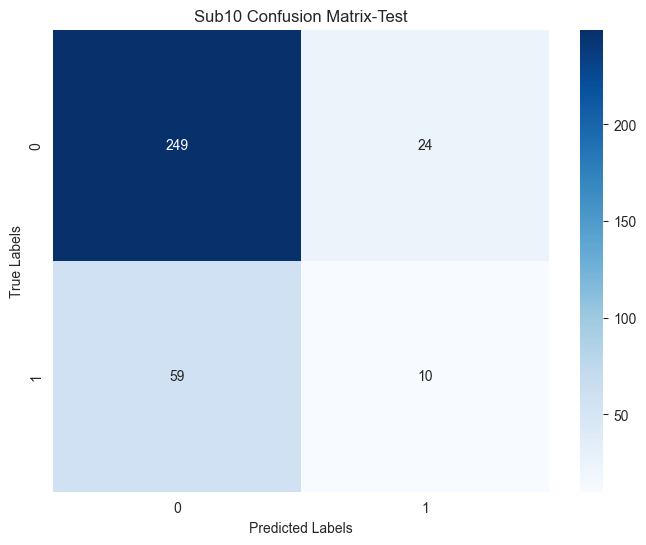

第 9 折（测试序号8）Acc: 75.73%

========== 开始第 10/22 折LOOCV（测试序号：9）==========
Fold [10/22], Epoch [1/500], Step [1/42], Loss: 0.6946
Fold [10/22], Epoch [1/500], Step [11/42], Loss: 0.6984
Fold [10/22], Epoch [1/500], Step [21/42], Loss: 0.6817
Fold [10/22], Epoch [1/500], Step [31/42], Loss: 0.6752
Fold [10/22], Epoch [1/500], Step [41/42], Loss: 0.6754
Fold [10/22], Epoch [101/500], Step [1/42], Loss: 0.5591
Fold [10/22], Epoch [101/500], Step [11/42], Loss: 0.4255
Fold [10/22], Epoch [101/500], Step [21/42], Loss: 0.3946
Fold [10/22], Epoch [101/500], Step [31/42], Loss: 0.4978
Fold [10/22], Epoch [101/500], Step [41/42], Loss: 0.4384
Fold [10/22], Epoch [201/500], Step [1/42], Loss: 0.4776
Fold [10/22], Epoch [201/500], Step [11/42], Loss: 0.4458
Fold [10/22], Epoch [201/500], Step [21/42], Loss: 0.4450
Fold [10/22], Epoch [201/500], Step [31/42], Loss: 0.4451
Fold [10/22], Epoch [201/500], Step [41/42], Loss: 0.4677
Fold [10/22], Epoch [301/500], Step [1/42], Loss: 0.5135
Fold [10/22], E

<Figure size 640x480 with 0 Axes>

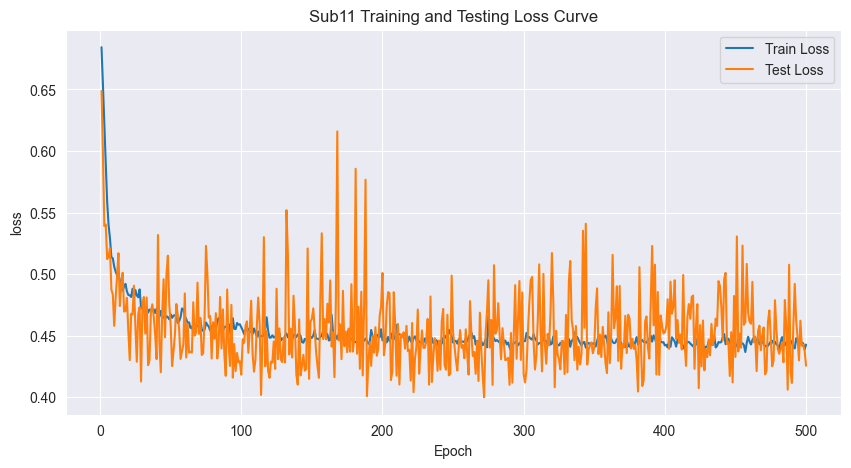

<Figure size 640x480 with 0 Axes>

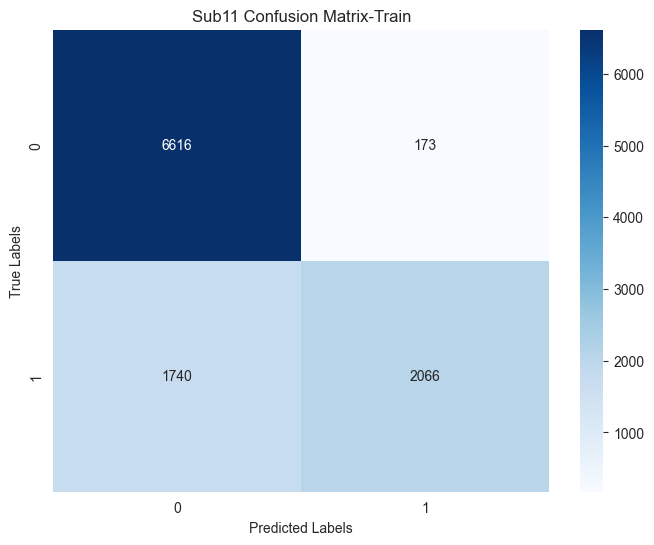

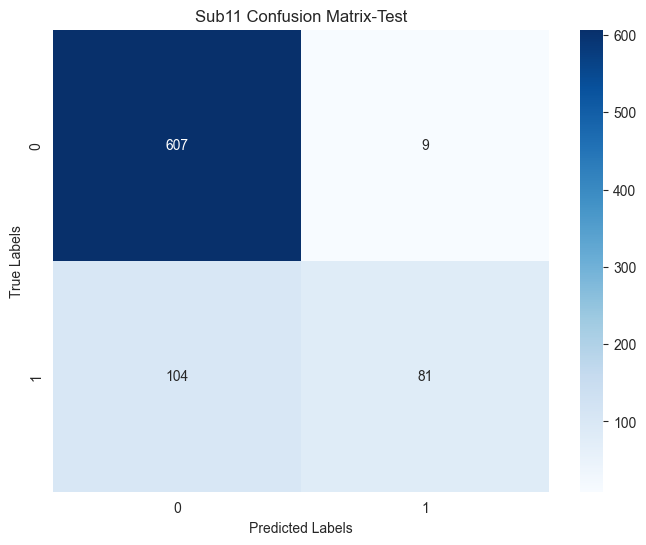

第 10 折（测试序号9）Acc: 85.89%

========== 开始第 11/22 折LOOCV（测试序号：10）==========
Fold [11/22], Epoch [1/500], Step [1/42], Loss: 0.7090
Fold [11/22], Epoch [1/500], Step [11/42], Loss: 0.6964
Fold [11/22], Epoch [1/500], Step [21/42], Loss: 0.6810
Fold [11/22], Epoch [1/500], Step [31/42], Loss: 0.6781
Fold [11/22], Epoch [1/500], Step [41/42], Loss: 0.6617
Fold [11/22], Epoch [101/500], Step [1/42], Loss: 0.4737
Fold [11/22], Epoch [101/500], Step [11/42], Loss: 0.4451
Fold [11/22], Epoch [101/500], Step [21/42], Loss: 0.4587
Fold [11/22], Epoch [101/500], Step [31/42], Loss: 0.4569
Fold [11/22], Epoch [101/500], Step [41/42], Loss: 0.4580
Fold [11/22], Epoch [201/500], Step [1/42], Loss: 0.4635
Fold [11/22], Epoch [201/500], Step [11/42], Loss: 0.4458
Fold [11/22], Epoch [201/500], Step [21/42], Loss: 0.4474
Fold [11/22], Epoch [201/500], Step [31/42], Loss: 0.4820
Fold [11/22], Epoch [201/500], Step [41/42], Loss: 0.4626
Fold [11/22], Epoch [301/500], Step [1/42], Loss: 0.4330
Fold [11/22],

<Figure size 640x480 with 0 Axes>

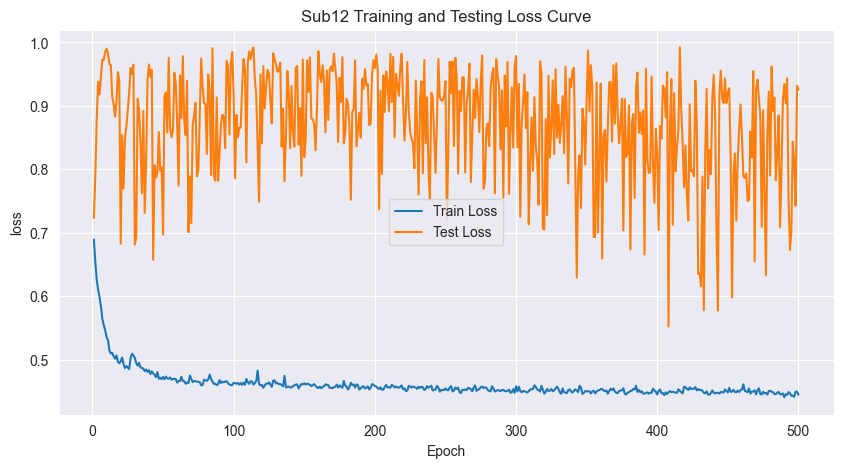

<Figure size 640x480 with 0 Axes>

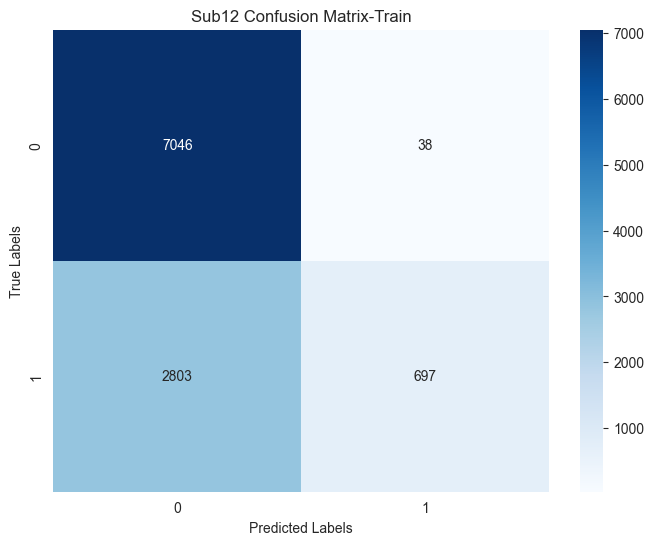

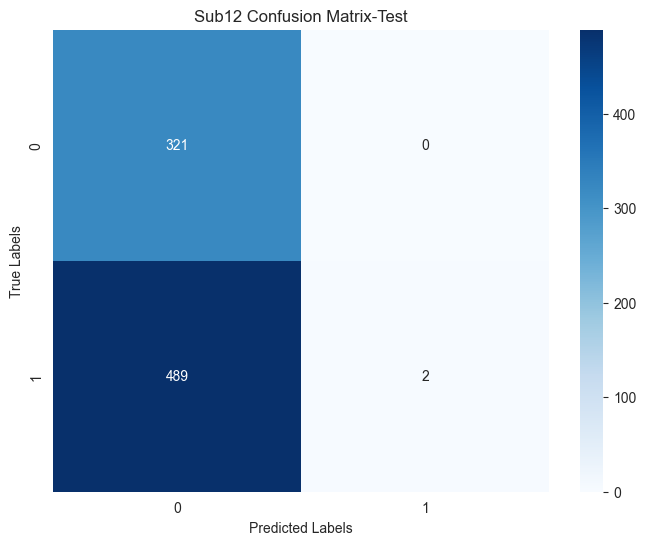

第 11 折（测试序号10）Acc: 39.78%

========== 开始第 12/22 折LOOCV（测试序号：11）==========
Fold [12/22], Epoch [1/500], Step [1/43], Loss: 0.6938
Fold [12/22], Epoch [1/500], Step [11/43], Loss: 0.6934
Fold [12/22], Epoch [1/500], Step [21/43], Loss: 0.6904
Fold [12/22], Epoch [1/500], Step [31/43], Loss: 0.6789
Fold [12/22], Epoch [1/500], Step [41/43], Loss: 0.6764
Fold [12/22], Epoch [101/500], Step [1/43], Loss: 0.4544
Fold [12/22], Epoch [101/500], Step [11/43], Loss: 0.4832
Fold [12/22], Epoch [101/500], Step [21/43], Loss: 0.4317
Fold [12/22], Epoch [101/500], Step [31/43], Loss: 0.4664
Fold [12/22], Epoch [101/500], Step [41/43], Loss: 0.4799
Fold [12/22], Epoch [201/500], Step [1/43], Loss: 0.5039
Fold [12/22], Epoch [201/500], Step [11/43], Loss: 0.4501
Fold [12/22], Epoch [201/500], Step [21/43], Loss: 0.4382
Fold [12/22], Epoch [201/500], Step [31/43], Loss: 0.4824
Fold [12/22], Epoch [201/500], Step [41/43], Loss: 0.5058
Fold [12/22], Epoch [301/500], Step [1/43], Loss: 0.4253
Fold [12/22]

<Figure size 640x480 with 0 Axes>

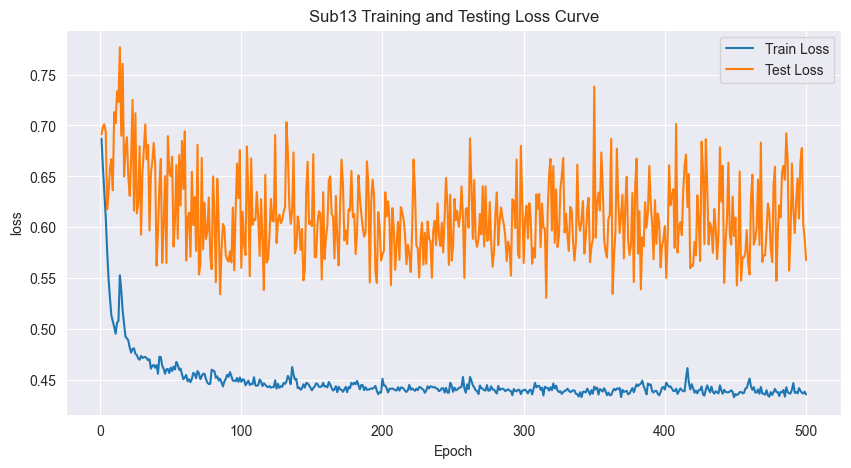

<Figure size 640x480 with 0 Axes>

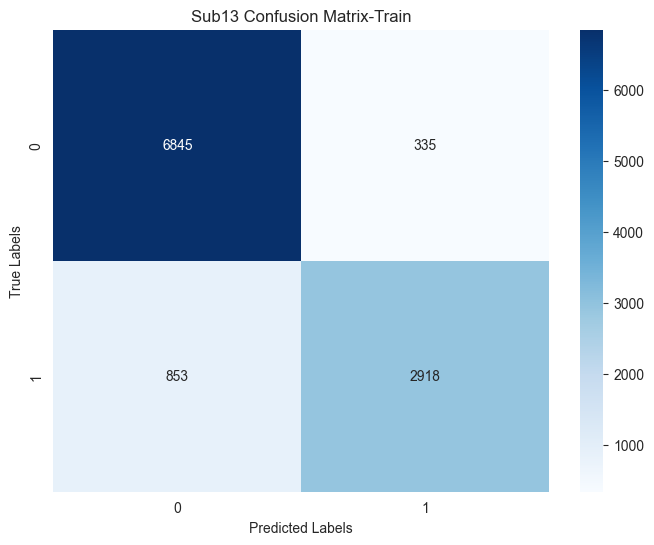

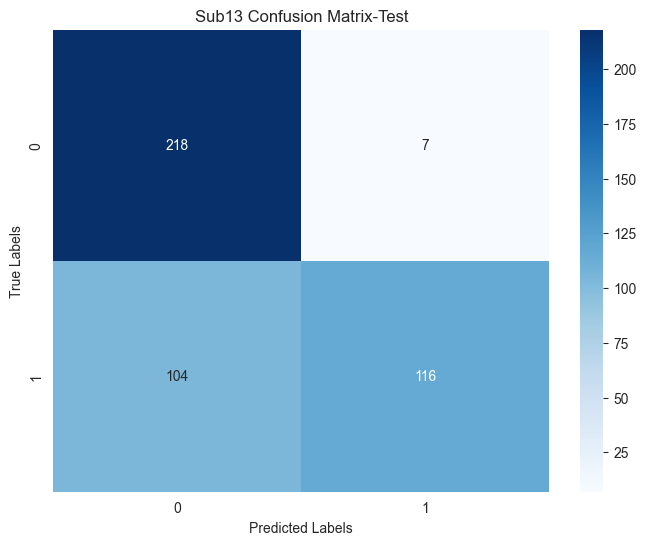

第 12 折（测试序号11）Acc: 75.06%

========== 开始第 13/22 折LOOCV（测试序号：12）==========
Fold [13/22], Epoch [1/500], Step [1/44], Loss: 0.6973
Fold [13/22], Epoch [1/500], Step [11/44], Loss: 0.6974
Fold [13/22], Epoch [1/500], Step [21/44], Loss: 0.6861
Fold [13/22], Epoch [1/500], Step [31/44], Loss: 0.6889
Fold [13/22], Epoch [1/500], Step [41/44], Loss: 0.6803
Fold [13/22], Epoch [101/500], Step [1/44], Loss: 0.4597
Fold [13/22], Epoch [101/500], Step [11/44], Loss: 0.4374
Fold [13/22], Epoch [101/500], Step [21/44], Loss: 0.4525
Fold [13/22], Epoch [101/500], Step [31/44], Loss: 0.4313
Fold [13/22], Epoch [101/500], Step [41/44], Loss: 0.4354
Fold [13/22], Epoch [201/500], Step [1/44], Loss: 0.4807
Fold [13/22], Epoch [201/500], Step [11/44], Loss: 0.4568
Fold [13/22], Epoch [201/500], Step [21/44], Loss: 0.4408
Fold [13/22], Epoch [201/500], Step [31/44], Loss: 0.4617
Fold [13/22], Epoch [201/500], Step [41/44], Loss: 0.4236
Fold [13/22], Epoch [301/500], Step [1/44], Loss: 0.4370
Fold [13/22]

<Figure size 640x480 with 0 Axes>

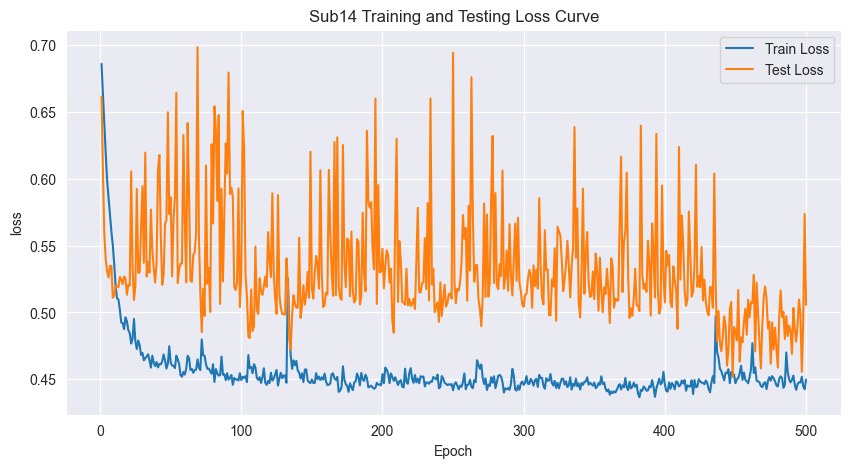

<Figure size 640x480 with 0 Axes>

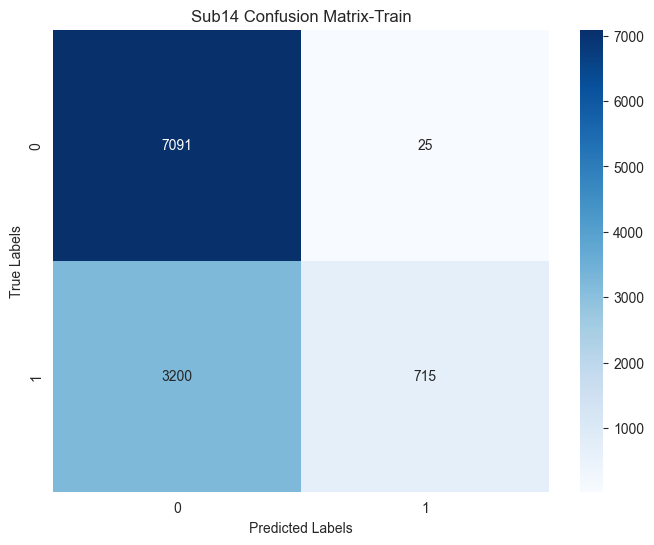

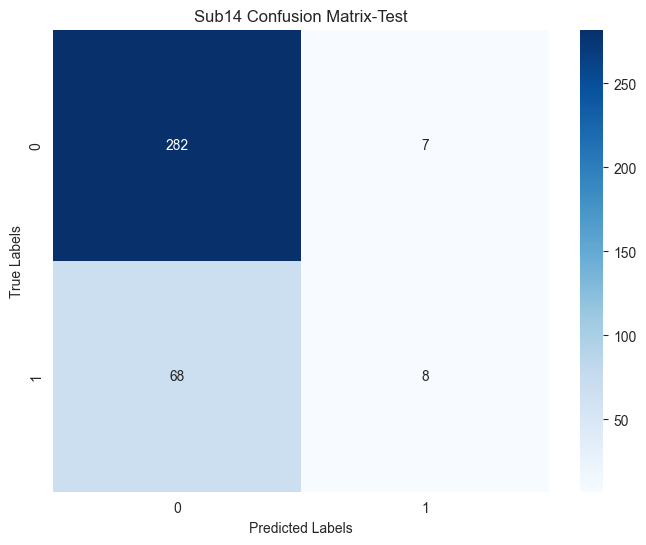

第 13 折（测试序号12）Acc: 79.45%

========== 开始第 14/22 折LOOCV（测试序号：13）==========
Fold [14/22], Epoch [1/500], Step [1/42], Loss: 0.6943
Fold [14/22], Epoch [1/500], Step [11/42], Loss: 0.6963
Fold [14/22], Epoch [1/500], Step [21/42], Loss: 0.6825
Fold [14/22], Epoch [1/500], Step [31/42], Loss: 0.6812
Fold [14/22], Epoch [1/500], Step [41/42], Loss: 0.6623
Fold [14/22], Epoch [101/500], Step [1/42], Loss: 0.4415
Fold [14/22], Epoch [101/500], Step [11/42], Loss: 0.4350
Fold [14/22], Epoch [101/500], Step [21/42], Loss: 0.4222
Fold [14/22], Epoch [101/500], Step [31/42], Loss: 0.4655
Fold [14/22], Epoch [101/500], Step [41/42], Loss: 0.4643
Fold [14/22], Epoch [201/500], Step [1/42], Loss: 0.4454
Fold [14/22], Epoch [201/500], Step [11/42], Loss: 0.4895
Fold [14/22], Epoch [201/500], Step [21/42], Loss: 0.4616
Fold [14/22], Epoch [201/500], Step [31/42], Loss: 0.4407
Fold [14/22], Epoch [201/500], Step [41/42], Loss: 0.4873
Fold [14/22], Epoch [301/500], Step [1/42], Loss: 0.4242
Fold [14/22]

<Figure size 640x480 with 0 Axes>

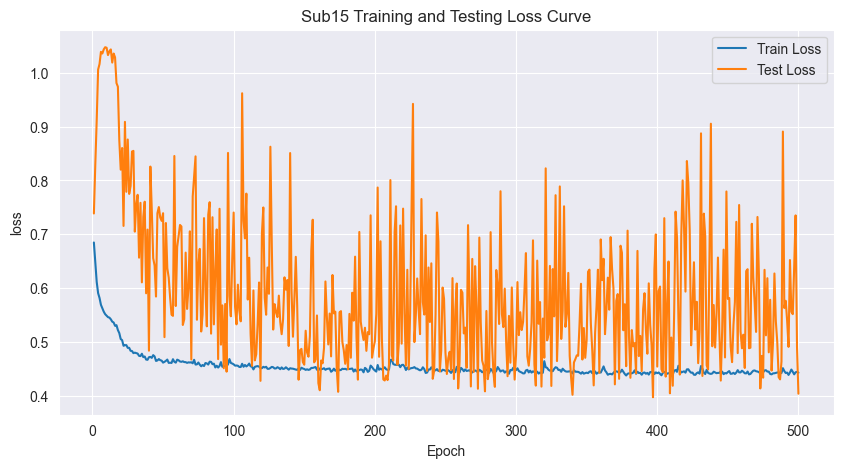

<Figure size 640x480 with 0 Axes>

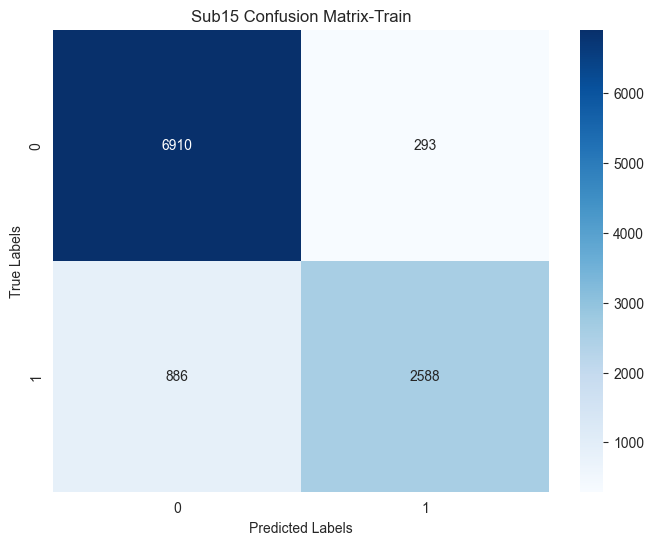

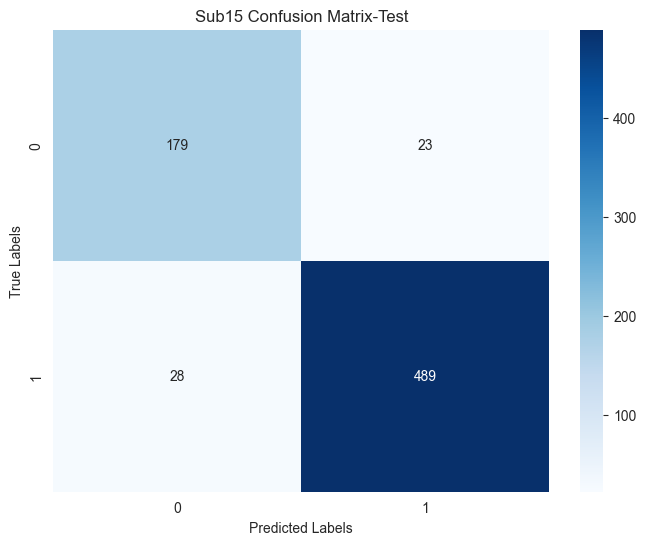

第 14 折（测试序号13）Acc: 92.91%

========== 开始第 15/22 折LOOCV（测试序号：14）==========
Fold [15/22], Epoch [1/500], Step [1/42], Loss: 0.6931
Fold [15/22], Epoch [1/500], Step [11/42], Loss: 0.6964
Fold [15/22], Epoch [1/500], Step [21/42], Loss: 0.6965
Fold [15/22], Epoch [1/500], Step [31/42], Loss: 0.6884
Fold [15/22], Epoch [1/500], Step [41/42], Loss: 0.6870
Fold [15/22], Epoch [101/500], Step [1/42], Loss: 0.4464
Fold [15/22], Epoch [101/500], Step [11/42], Loss: 0.4163
Fold [15/22], Epoch [101/500], Step [21/42], Loss: 0.4343
Fold [15/22], Epoch [101/500], Step [31/42], Loss: 0.4504
Fold [15/22], Epoch [101/500], Step [41/42], Loss: 0.4342
Fold [15/22], Epoch [201/500], Step [1/42], Loss: 0.6085
Fold [15/22], Epoch [201/500], Step [11/42], Loss: 0.4200
Fold [15/22], Epoch [201/500], Step [21/42], Loss: 0.4399
Fold [15/22], Epoch [201/500], Step [31/42], Loss: 0.4437
Fold [15/22], Epoch [201/500], Step [41/42], Loss: 0.4245
Fold [15/22], Epoch [301/500], Step [1/42], Loss: 0.4445
Fold [15/22]

<Figure size 640x480 with 0 Axes>

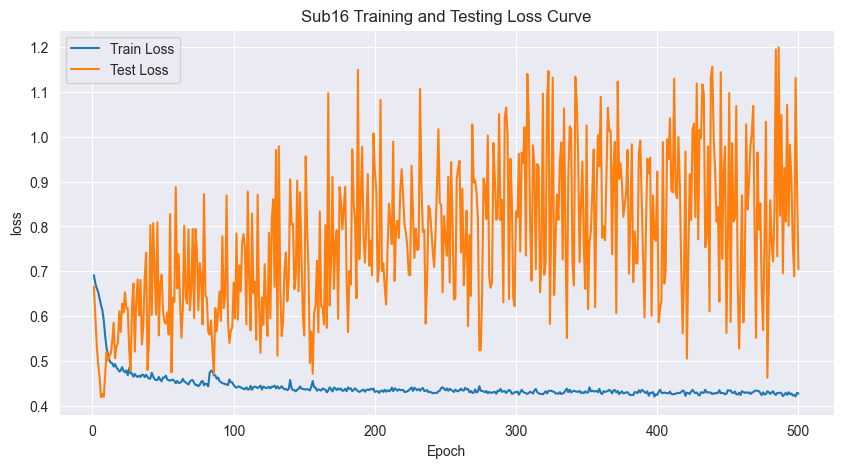

<Figure size 640x480 with 0 Axes>

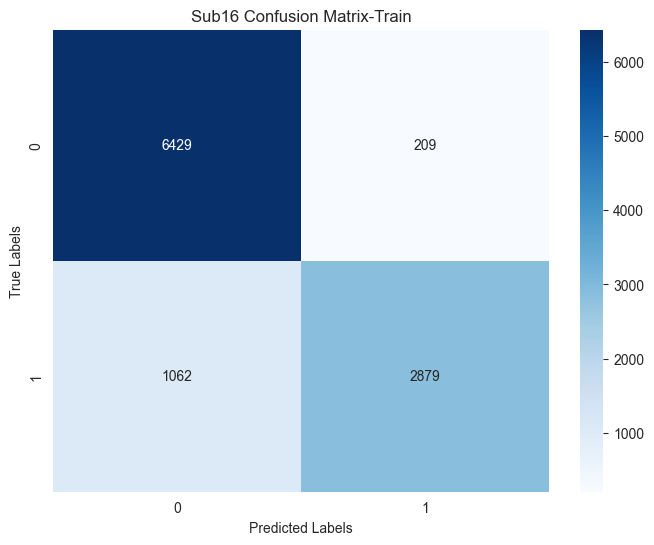

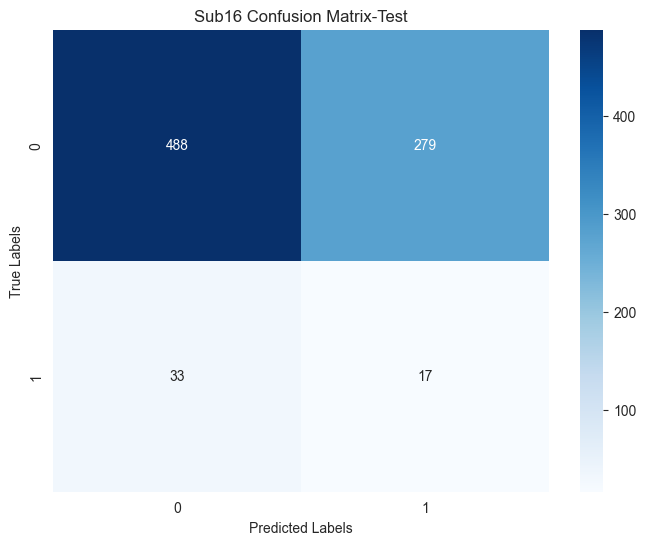

第 15 折（测试序号14）Acc: 61.81%

========== 开始第 16/22 折LOOCV（测试序号：15）==========
Fold [16/22], Epoch [1/500], Step [1/42], Loss: 0.6929
Fold [16/22], Epoch [1/500], Step [11/42], Loss: 0.6926
Fold [16/22], Epoch [1/500], Step [21/42], Loss: 0.6846
Fold [16/22], Epoch [1/500], Step [31/42], Loss: 0.6746
Fold [16/22], Epoch [1/500], Step [41/42], Loss: 0.6719
Fold [16/22], Epoch [101/500], Step [1/42], Loss: 0.4213
Fold [16/22], Epoch [101/500], Step [11/42], Loss: 0.4403
Fold [16/22], Epoch [101/500], Step [21/42], Loss: 0.4712
Fold [16/22], Epoch [101/500], Step [31/42], Loss: 0.5278
Fold [16/22], Epoch [101/500], Step [41/42], Loss: 0.4713
Fold [16/22], Epoch [201/500], Step [1/42], Loss: 0.4267
Fold [16/22], Epoch [201/500], Step [11/42], Loss: 0.4432
Fold [16/22], Epoch [201/500], Step [21/42], Loss: 0.4690
Fold [16/22], Epoch [201/500], Step [31/42], Loss: 0.4900
Fold [16/22], Epoch [201/500], Step [41/42], Loss: 0.4565
Fold [16/22], Epoch [301/500], Step [1/42], Loss: 0.4228
Fold [16/22]

<Figure size 640x480 with 0 Axes>

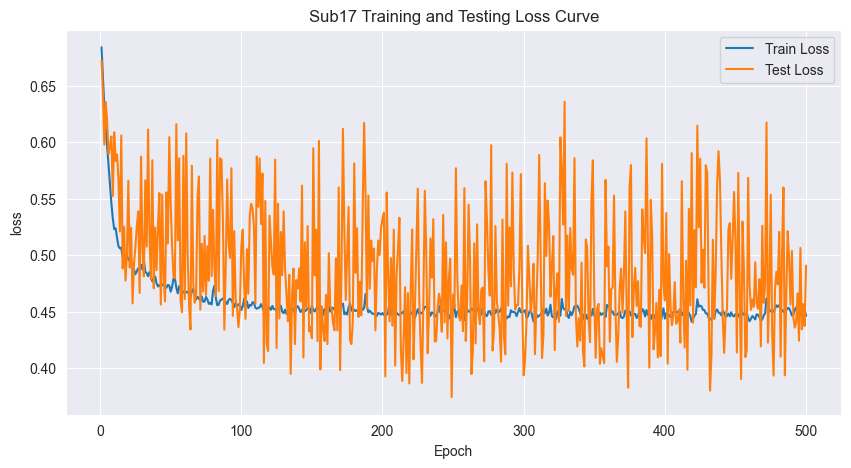

<Figure size 640x480 with 0 Axes>

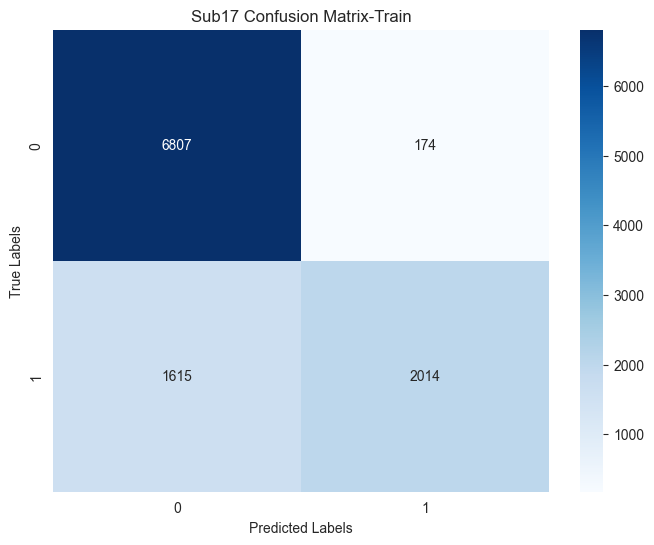

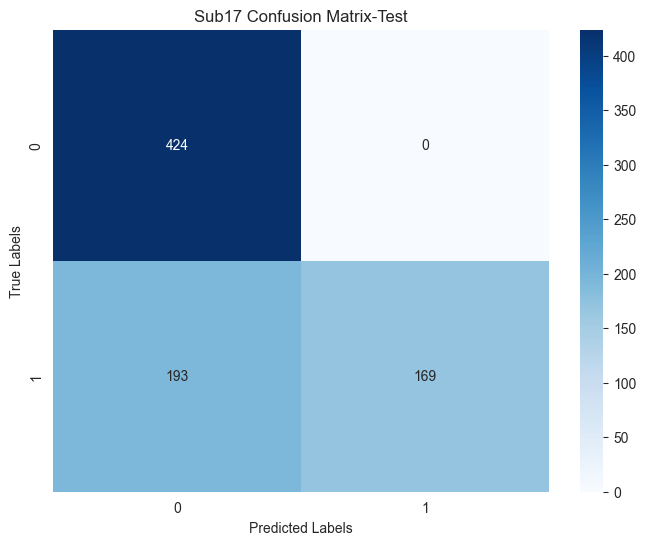

第 16 折（测试序号15）Acc: 75.45%

========== 开始第 17/22 折LOOCV（测试序号：16）==========
Fold [17/22], Epoch [1/500], Step [1/44], Loss: 0.6848
Fold [17/22], Epoch [1/500], Step [11/44], Loss: 0.6851
Fold [17/22], Epoch [1/500], Step [21/44], Loss: 0.6842
Fold [17/22], Epoch [1/500], Step [31/44], Loss: 0.6746
Fold [17/22], Epoch [1/500], Step [41/44], Loss: 0.6757
Fold [17/22], Epoch [101/500], Step [1/44], Loss: 0.4819
Fold [17/22], Epoch [101/500], Step [11/44], Loss: 0.4511
Fold [17/22], Epoch [101/500], Step [21/44], Loss: 0.4871
Fold [17/22], Epoch [101/500], Step [31/44], Loss: 0.4561
Fold [17/22], Epoch [101/500], Step [41/44], Loss: 0.4408
Fold [17/22], Epoch [201/500], Step [1/44], Loss: 0.4283
Fold [17/22], Epoch [201/500], Step [11/44], Loss: 0.4646
Fold [17/22], Epoch [201/500], Step [21/44], Loss: 0.4350
Fold [17/22], Epoch [201/500], Step [31/44], Loss: 0.4392
Fold [17/22], Epoch [201/500], Step [41/44], Loss: 0.4428
Fold [17/22], Epoch [301/500], Step [1/44], Loss: 0.4114
Fold [17/22]

<Figure size 640x480 with 0 Axes>

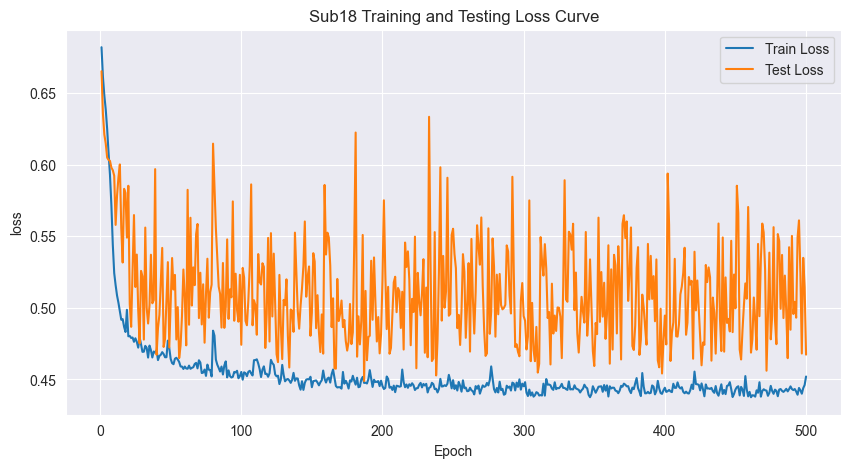

<Figure size 640x480 with 0 Axes>

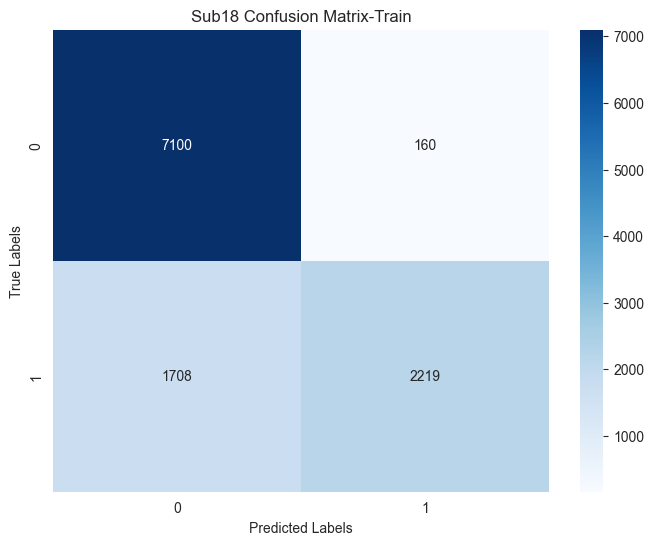

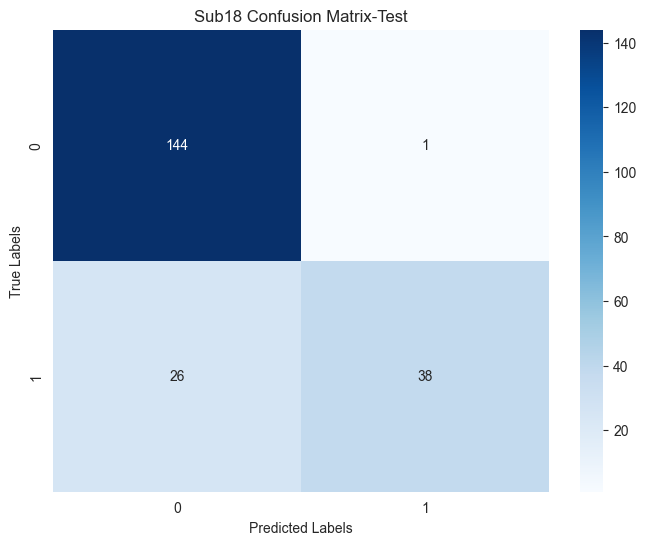

第 17 折（测试序号16）Acc: 87.08%

========== 开始第 18/22 折LOOCV（测试序号：17）==========
Fold [18/22], Epoch [1/500], Step [1/42], Loss: 0.6930
Fold [18/22], Epoch [1/500], Step [11/42], Loss: 0.6934
Fold [18/22], Epoch [1/500], Step [21/42], Loss: 0.6778
Fold [18/22], Epoch [1/500], Step [31/42], Loss: 0.6652
Fold [18/22], Epoch [1/500], Step [41/42], Loss: 0.6594
Fold [18/22], Epoch [101/500], Step [1/42], Loss: 0.4399
Fold [18/22], Epoch [101/500], Step [11/42], Loss: 0.4437
Fold [18/22], Epoch [101/500], Step [21/42], Loss: 0.4465
Fold [18/22], Epoch [101/500], Step [31/42], Loss: 0.4865
Fold [18/22], Epoch [101/500], Step [41/42], Loss: 0.4369
Fold [18/22], Epoch [201/500], Step [1/42], Loss: 0.4649
Fold [18/22], Epoch [201/500], Step [11/42], Loss: 0.4845
Fold [18/22], Epoch [201/500], Step [21/42], Loss: 0.4426
Fold [18/22], Epoch [201/500], Step [31/42], Loss: 0.4395
Fold [18/22], Epoch [201/500], Step [41/42], Loss: 0.5010
Fold [18/22], Epoch [301/500], Step [1/42], Loss: 0.4171
Fold [18/22]

<Figure size 640x480 with 0 Axes>

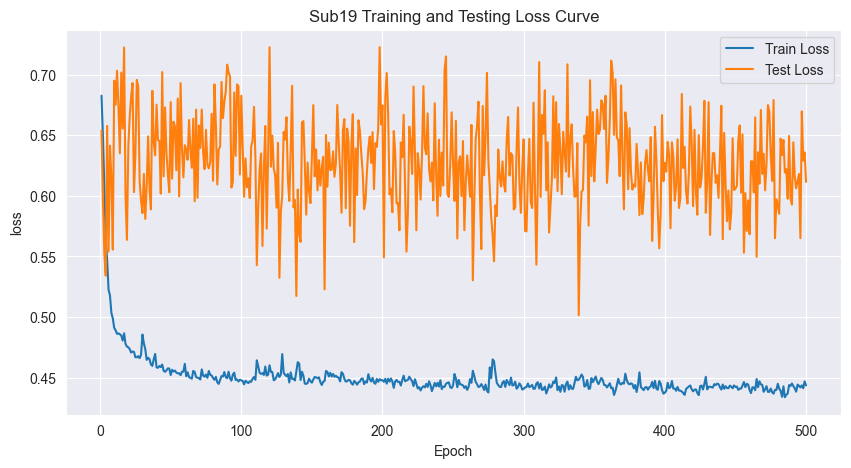

<Figure size 640x480 with 0 Axes>

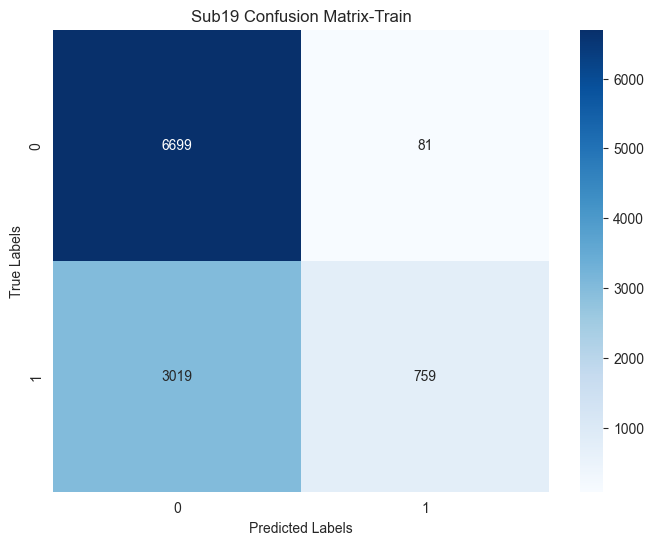

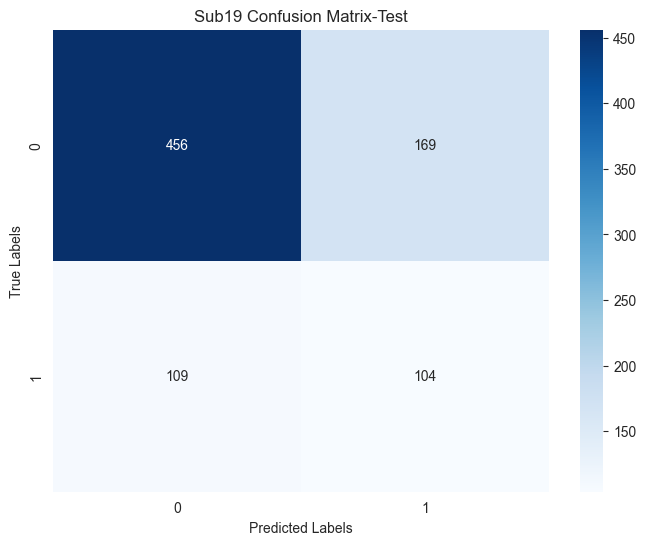

第 18 折（测试序号17）Acc: 66.83%

========== 开始第 19/22 折LOOCV（测试序号：18）==========
Fold [19/22], Epoch [1/500], Step [1/44], Loss: 0.6954
Fold [19/22], Epoch [1/500], Step [11/44], Loss: 0.6921
Fold [19/22], Epoch [1/500], Step [21/44], Loss: 0.6952
Fold [19/22], Epoch [1/500], Step [31/44], Loss: 0.6909
Fold [19/22], Epoch [1/500], Step [41/44], Loss: 0.6809
Fold [19/22], Epoch [101/500], Step [1/44], Loss: 0.4400
Fold [19/22], Epoch [101/500], Step [11/44], Loss: 0.4323
Fold [19/22], Epoch [101/500], Step [21/44], Loss: 0.4299
Fold [19/22], Epoch [101/500], Step [31/44], Loss: 0.4516
Fold [19/22], Epoch [101/500], Step [41/44], Loss: 0.4358
Fold [19/22], Epoch [201/500], Step [1/44], Loss: 0.5212
Fold [19/22], Epoch [201/500], Step [11/44], Loss: 0.4277
Fold [19/22], Epoch [201/500], Step [21/44], Loss: 0.4271
Fold [19/22], Epoch [201/500], Step [31/44], Loss: 0.4244
Fold [19/22], Epoch [201/500], Step [41/44], Loss: 0.4271
Fold [19/22], Epoch [301/500], Step [1/44], Loss: 0.4541
Fold [19/22]

<Figure size 640x480 with 0 Axes>

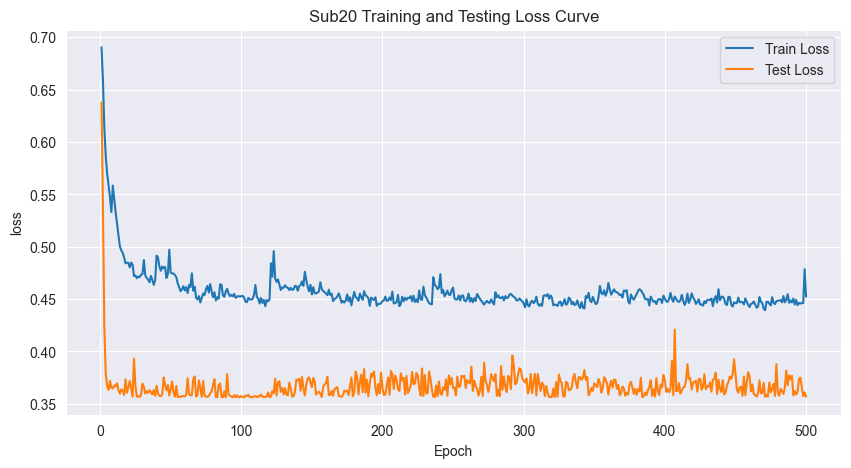

<Figure size 640x480 with 0 Axes>

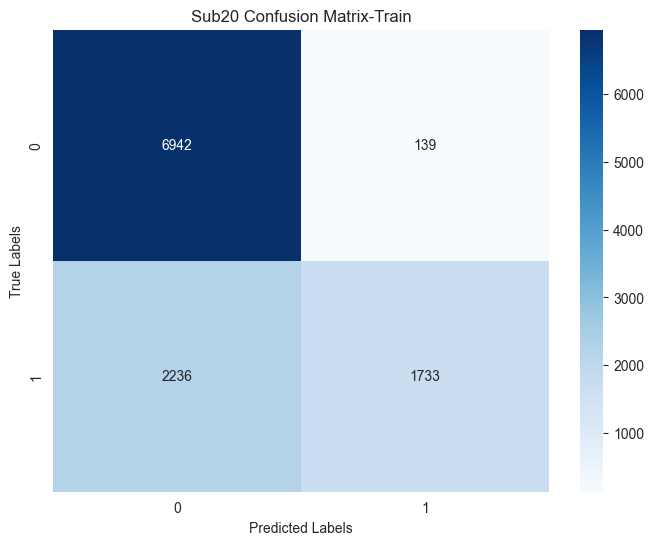

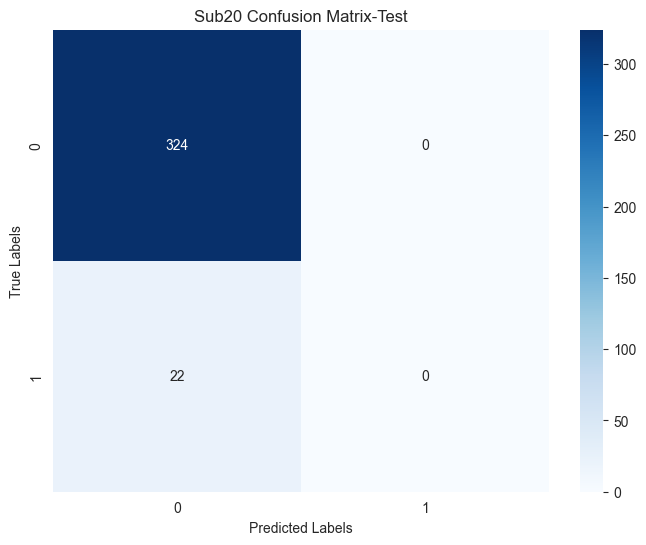

第 19 折（测试序号18）Acc: 93.64%

========== 开始第 20/22 折LOOCV（测试序号：19）==========
Fold [20/22], Epoch [1/500], Step [1/44], Loss: 0.6908
Fold [20/22], Epoch [1/500], Step [11/44], Loss: 0.6837
Fold [20/22], Epoch [1/500], Step [21/44], Loss: 0.6826
Fold [20/22], Epoch [1/500], Step [31/44], Loss: 0.6716
Fold [20/22], Epoch [1/500], Step [41/44], Loss: 0.6696
Fold [20/22], Epoch [101/500], Step [1/44], Loss: 0.4633
Fold [20/22], Epoch [101/500], Step [11/44], Loss: 0.4285
Fold [20/22], Epoch [101/500], Step [21/44], Loss: 0.4572
Fold [20/22], Epoch [101/500], Step [31/44], Loss: 0.4472
Fold [20/22], Epoch [101/500], Step [41/44], Loss: 0.4177
Fold [20/22], Epoch [201/500], Step [1/44], Loss: 0.4205
Fold [20/22], Epoch [201/500], Step [11/44], Loss: 0.4853
Fold [20/22], Epoch [201/500], Step [21/44], Loss: 0.4487
Fold [20/22], Epoch [201/500], Step [31/44], Loss: 0.5126
Fold [20/22], Epoch [201/500], Step [41/44], Loss: 0.4858
Fold [20/22], Epoch [301/500], Step [1/44], Loss: 0.4161
Fold [20/22]

<Figure size 640x480 with 0 Axes>

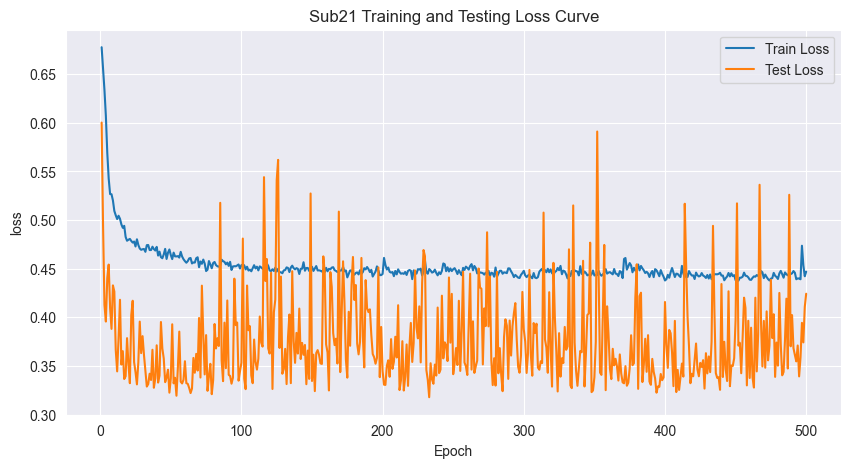

<Figure size 640x480 with 0 Axes>

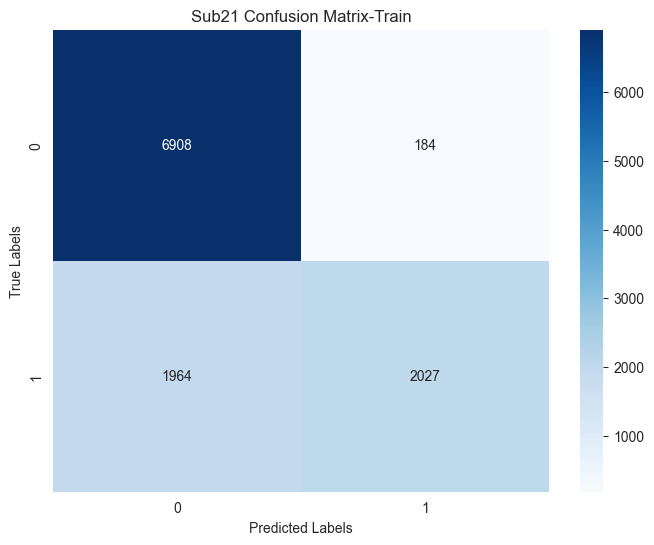

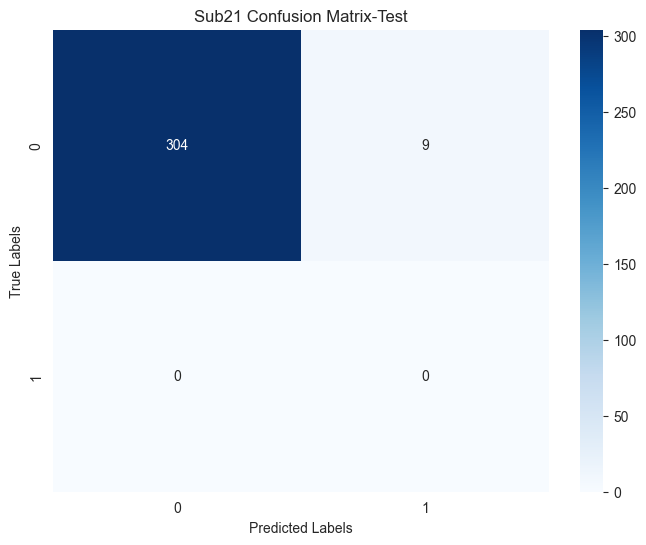

第 20 折（测试序号19）Acc: 97.12%

========== 开始第 21/22 折LOOCV（测试序号：20）==========
Fold [21/22], Epoch [1/500], Step [1/42], Loss: 0.6934
Fold [21/22], Epoch [1/500], Step [11/42], Loss: 0.7018
Fold [21/22], Epoch [1/500], Step [21/42], Loss: 0.6882
Fold [21/22], Epoch [1/500], Step [31/42], Loss: 0.6850
Fold [21/22], Epoch [1/500], Step [41/42], Loss: 0.6737
Fold [21/22], Epoch [101/500], Step [1/42], Loss: 0.4398
Fold [21/22], Epoch [101/500], Step [11/42], Loss: 0.4393
Fold [21/22], Epoch [101/500], Step [21/42], Loss: 0.4790
Fold [21/22], Epoch [101/500], Step [31/42], Loss: 0.4541
Fold [21/22], Epoch [101/500], Step [41/42], Loss: 0.4534
Fold [21/22], Epoch [201/500], Step [1/42], Loss: 0.4603
Fold [21/22], Epoch [201/500], Step [11/42], Loss: 0.4268
Fold [21/22], Epoch [201/500], Step [21/42], Loss: 0.4529
Fold [21/22], Epoch [201/500], Step [31/42], Loss: 0.4377
Fold [21/22], Epoch [201/500], Step [41/42], Loss: 0.4198
Fold [21/22], Epoch [301/500], Step [1/42], Loss: 0.4408
Fold [21/22]

<Figure size 640x480 with 0 Axes>

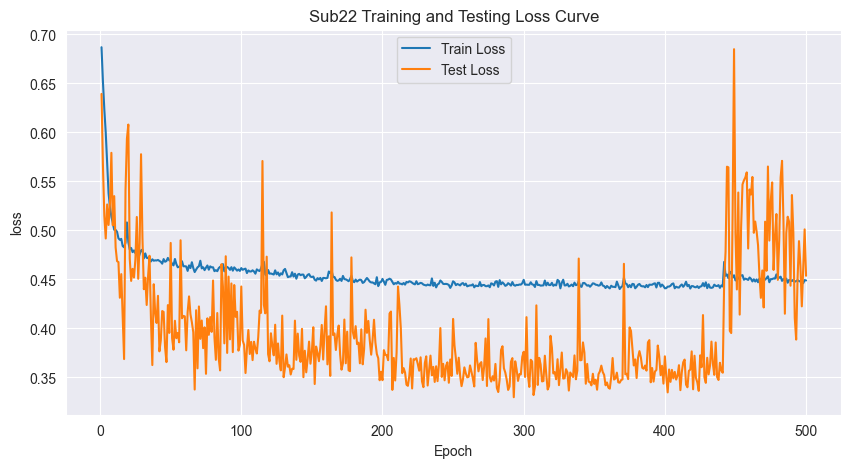

<Figure size 640x480 with 0 Axes>

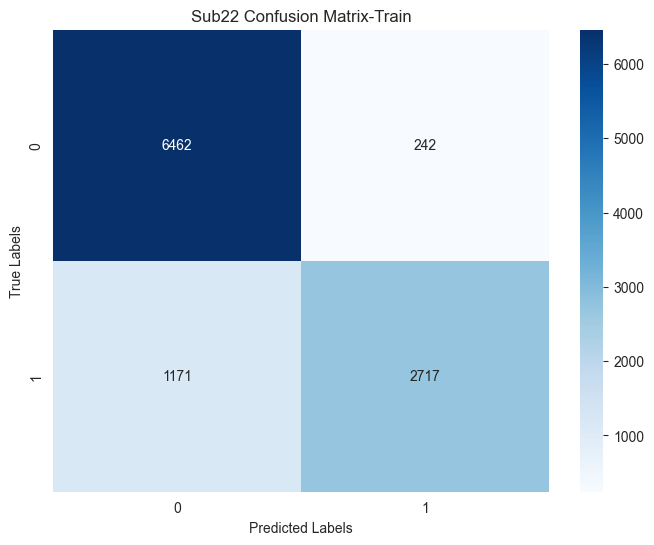

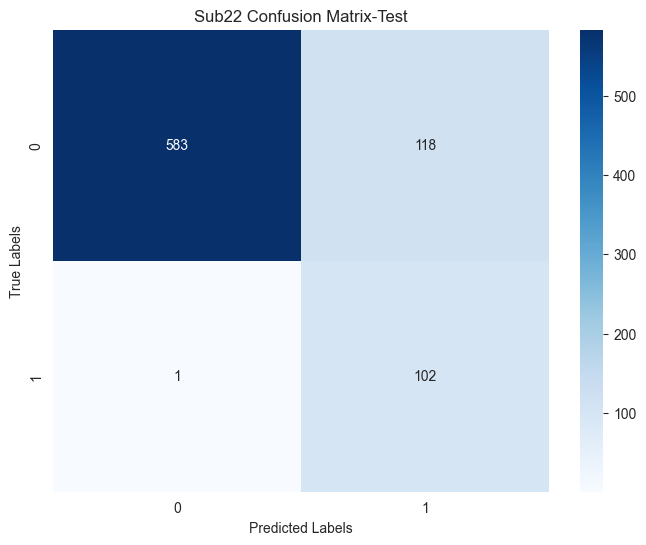

第 21 折（测试序号20）Acc: 85.20%

========== 开始第 22/22 折LOOCV（测试序号：21）==========
Fold [22/22], Epoch [1/500], Step [1/44], Loss: 0.6915
Fold [22/22], Epoch [1/500], Step [11/44], Loss: 0.6940
Fold [22/22], Epoch [1/500], Step [21/44], Loss: 0.6917
Fold [22/22], Epoch [1/500], Step [31/44], Loss: 0.6798
Fold [22/22], Epoch [1/500], Step [41/44], Loss: 0.6638
Fold [22/22], Epoch [101/500], Step [1/44], Loss: 0.4448
Fold [22/22], Epoch [101/500], Step [11/44], Loss: 0.4716
Fold [22/22], Epoch [101/500], Step [21/44], Loss: 0.4058
Fold [22/22], Epoch [101/500], Step [31/44], Loss: 0.4684
Fold [22/22], Epoch [101/500], Step [41/44], Loss: 0.4543
Fold [22/22], Epoch [201/500], Step [1/44], Loss: 0.4354
Fold [22/22], Epoch [201/500], Step [11/44], Loss: 0.4406
Fold [22/22], Epoch [201/500], Step [21/44], Loss: 0.4329
Fold [22/22], Epoch [201/500], Step [31/44], Loss: 0.4527
Fold [22/22], Epoch [201/500], Step [41/44], Loss: 0.4195
Fold [22/22], Epoch [301/500], Step [1/44], Loss: 0.4346
Fold [22/22]

<Figure size 640x480 with 0 Axes>

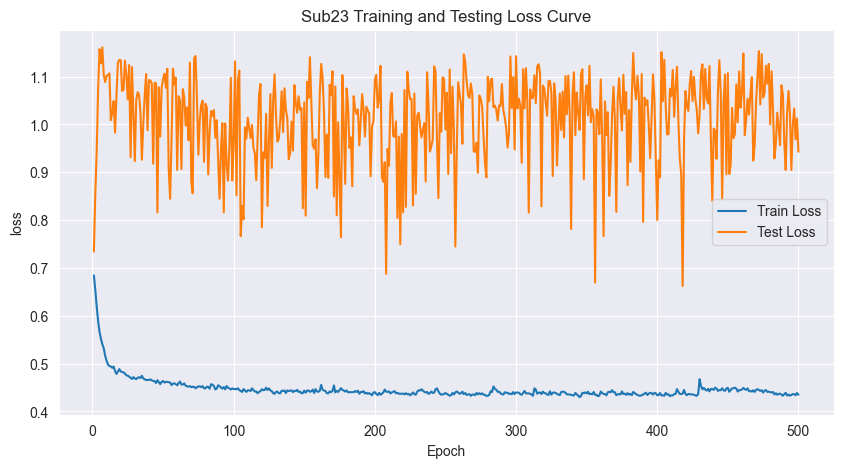

<Figure size 640x480 with 0 Axes>

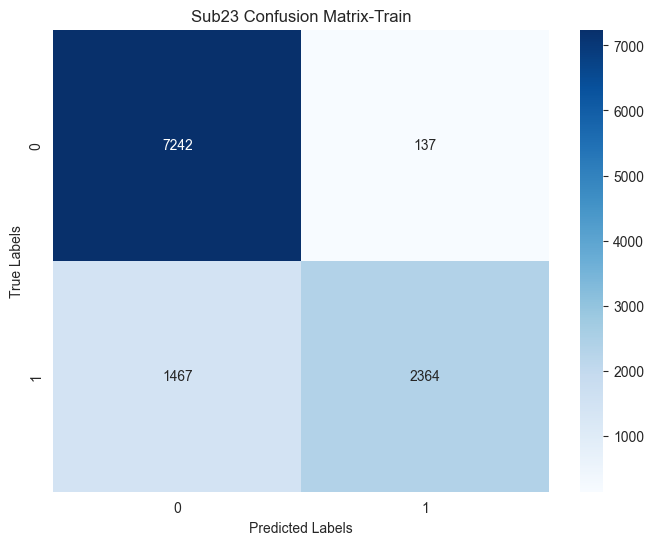

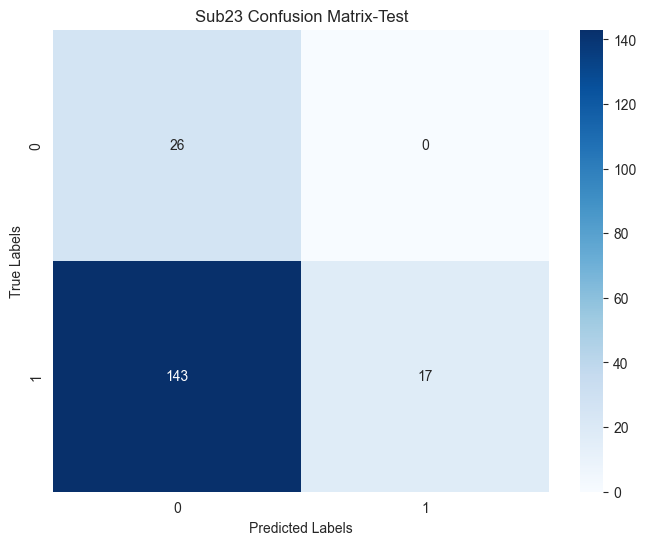

第 22 折（测试序号21）Acc: 23.12%

========== LOOCV最终结果 ==========
11折平均测试准确率: 71.69% (标准差: 20.03%)


<Figure size 640x480 with 0 Axes>

In [23]:
datas = []
test_datas = []

# 定义超参数（保持不变）
lr = 0.01
wd = 0.001
bs = 256
op = 'SGD'
dr = 0.5
epoches = 500
all_loocv_accuracies = []  # 新增：保存11次LOOCV的准确率
all_loocv_train_losses = []  # 新增：保存11次的训练损失
all_loocv_test_losses = []   # 新增：保存11次的测试损失

# 原始数据处理（保持不变）
predata = torch.Tensor(EEGsample)
label = torch.Tensor(substate).long().squeeze()
index = torch.Tensor(subindex).long().squeeze() - 1 # index是0-21
inpt = predata.reshape(-1, 1, 17, 384) # (11396,1,17,384)

# 提取所有唯一的样本序号（0-10），共11个
unique_index = torch.unique(index).numpy()
n_folds = len(unique_index)  # LOOCV的折数=11

# ====================== 核心：LOOCV循环 ======================
for fold_idx, test_idx in enumerate(unique_index):
    print(f"\n========== 开始第 {fold_idx+1}/{n_folds} 折LOOCV（测试序号：{test_idx}）==========")

    # 1. 划分本次LOOCV的训练/测试序号
    train_index_ids = [idx for idx in unique_index if idx != test_idx]  # 剩余10个作为训练
    test_index_ids = [test_idx]  # 留1个作为测试

    # 2. 生成训练/测试掩码
    train_mask = torch.zeros_like(index, dtype=torch.bool)
    for idx in train_index_ids:
        train_mask = train_mask | (index == idx)

    test_mask = torch.zeros_like(index, dtype=torch.bool)
    test_mask = test_mask | (index == test_idx)

    # === 关键修复：去掉多余维度 ===
    train_mask = train_mask.squeeze()   # 从 [1, 11396] → [11396]
    test_mask  = test_mask.squeeze()

    # 3. 拆分训练/测试数据
    train_inpt = inpt[train_mask]
    train_label = label[train_mask]
    test_inpt = inpt[test_mask]
    test_label = label[test_mask]

    # 3. 拆分训练/测试数据
    train_inpt = inpt[train_mask]
    train_label = label[train_mask]
    test_inpt = inpt[test_mask]
    test_label = label[test_mask]

    # 4. 构建数据集和DataLoader
    train_dataset = TensorDataset(train_inpt, train_label)
    test_dataset = TensorDataset(test_inpt, test_label)
    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=bs, shuffle=False)

    # 5. 重新初始化模型/优化器（关键！LOOCV每次必须重新初始化）
    # device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # device = torch.device("cpu")  # 强制CPU
    net = EEGNet(drop_out = dr).to(device)

    criterion = nn.CrossEntropyLoss().to(device)
    if op == 'Adam':
        optimizer = optim.Adam(net.parameters(),lr = lr,weight_decay=wd)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epoches, eta_min=0)
    else:
        optimizer = optim.SGD(net.parameters(),lr = lr,weight_decay=wd,momentum=0.9,nesterov=True)

    # 初始化本次折的损失记录
    train_losses = []
    test_losses = []

    # 6. 训练模型（和你原有训练逻辑一致）
    for epoch in range(epoches):
        net.train()
        train_loss = 0.0

        for i, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            if op == 'Adam':
                scheduler.step()

            # 打印日志（仅每100epoch+每10step）
            if epoch%100==0 and i %10==0:
                print(f'Fold [{fold_idx+1}/{n_folds}], Epoch [{epoch+1}/{epoches}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
            train_loss += loss.item()

        # 验证阶段
        net.eval()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        test_losses = get_losses(test_losses, test_loader, net, device)

    # 7. 评估本次折的模型
    net.eval()
    # 获取预测结果
    all_train_targets, all_train_predictions = get_predictions(train_loader, net, device)
    all_test_targets, all_test_predictions = get_predictions(test_loader, net, device)

    # 保存本次折的损失/可视化（可选，按需求调整路径）
    sub_path = os.path.join(path, 'EEGNet', f'fold_{fold_idx+1}_testidx_{test_idx}')
    os.makedirs(sub_path, exist_ok=True)
    loss_curve(epoches, train_losses, test_losses, folder_path=sub_path, sub=fold_idx+1)
    plt.clf()
    plot_confusion_matrix(all_train_targets,all_train_predictions,all_test_targets,all_test_predictions,folder_path=sub_path, sub=fold_idx+1)
    plt.clf()

    # 计算本次折的准确率
    test_accuracy = calculate_accuracy(test_loader, net, device)
    all_loocv_accuracies.append(test_accuracy)
    print(f'第 {fold_idx+1} 折（测试序号{test_idx}）Acc: {test_accuracy:.2f}%')

    # 保存本次折的损失
    all_loocv_train_losses.append(train_losses)
    all_loocv_test_losses.append(test_losses)

    # 写入单次折的结果到报告
    with open(report_path, 'a') as f:
        f.write(f'LOOCV Fold {fold_idx+1}（测试序号{test_idx}）Acc: {test_accuracy:.2f}%\n')

# ====================== LOOCV结束：计算最终结果 ======================
# 计算11次折的平均准确率
mean_loocv_accuracy = np.mean(all_loocv_accuracies)
std_loocv_accuracy = np.std(all_loocv_accuracies)  # 标准差，评估稳定性
print(f"\n========== LOOCV最终结果 ==========")
print(f'11折平均测试准确率: {mean_loocv_accuracy:.2f}% (标准差: {std_loocv_accuracy:.2f}%)')

# 写入最终结果到报告
with open(report_path, 'a') as f:
    f.write(f'\nLOOCV 11折平均准确率: {mean_loocv_accuracy:.2f}% (标准差: {std_loocv_accuracy:.2f}%)\n')
    f.write(f'各折准确率: {[f"{acc:.2f}%" for acc in all_loocv_accuracies]}\n')